# CCUS-EOR 投资决策模型：一键复现

本 notebook 与 `ccus_part1.py`、`ccus_part2senario.py`、`ccus_part3.py` 等脚本放在同一目录，
**从第 0 个 cell 依次运行到底**即可得到论文与支撑材料的全部结果。

| cell | 内容 | 产出 | 大致耗时 |
|---|---|---|---|
| 0 | 环境与工作目录设置（必先运行） | — | 秒 |
| 1 | `ccus_part1.py` 基准模型 | 表2、图2–图4、`ccus_part1_results.csv` 等 | 2–4 分钟 |
| 2 | `ccus_part2senario.py` 政策情景与组合情景 | 表3–表5、图5–图8、`ccus_scenario_*.csv` | 30–45 分钟 |
| 3 | `ccus_part3.py` 参数敏感性 | 附录 A、`ccus_sensitivity_*.csv` | 20–30 分钟 |
| 4 | `decompose.py` + `analyze_combos.py` | `benchmarks.json`、`ccus_combination_summary.csv` | 2–3 分钟 |
| 5 | `diagnostics.py` 对照实验与误差诊断 | `diagnostics_results.json`、`diag_convergence.png` | 30–45 分钟 |
| 6 | `net_emissions.py` 全周期净排放核算 | 控制台输出 | 秒 |
| 7 | `fetch_45q.py` + `grep45q.py` + `exp_45q.py` 45Q 复核 | `45q_sources/*.txt` | 3–5 分钟 |
| 8 | 产物清单 | — | 秒 |

**运行前须知**

1. 三个主脚本互不调用，各自复制了一份模型类；改动参数时需三处同步，可用
   `compare_params.py` 核对。
2. 最慢的一步是 LSMC 的 NPV 预计算（路径数 × 决策点数）。若只想快速跑通流程，
   把下个 cell 里的 `QUICK_TEST` 改成 `True`（每个脚本 300 条路径，全部约 2 分钟），
   但结果仅用于自检，不能作为论文数值。
3. 在无图形界面的环境下运行请先设置 `MPLBACKEND=Agg`，否则画图窗口会阻塞进程。
4. 所有脚本使用固定随机种子，情景与基准共用同一批价格路径，因此情景差异不是抽样噪声。


In [1]:
# ============ 0. 环境与工作目录设置（先运行本 cell） ============
import os
import sys
import time
import runpy
import builtins
from pathlib import Path

# 快速自检开关：True = 仅用 300 条路径跑通全流程（约 1-2 分钟）；正式结果请设为 False
QUICK_TEST = False
if QUICK_TEST:
    os.environ["CCUS_QUICK_TEST"] = "1"
else:
    os.environ.pop("CCUS_QUICK_TEST", None)

# 工作目录 = 本 notebook 所在目录（三个 py 文件必须放在这里）
BASE_DIR = Path.cwd()
os.chdir(BASE_DIR)
# 让主脚本在无交互环境下自动作答、绝不阻塞（ccus_part1.py 末尾有一处询问）
os.environ.setdefault("CCUS_NONINTERACTIVE", "1")
os.environ.setdefault("CCUS_SHOW_DETAILED", "y")
SCRIPTS = ["ccus_part1.py", "ccus_part2senario.py", "ccus_part3.py"]
missing = [s for s in SCRIPTS if not (BASE_DIR / s).exists()]
print("工作目录:", BASE_DIR)
print("脚本检查:", "三个脚本均已找到" if not missing else "缺少 %s" % missing)
print("快速自检模式:", "开启（300 条路径）" if QUICK_TEST else "关闭（按脚本设定的路径数运行）")

# 依赖检查
import numpy as np
import pandas as pd
import matplotlib
try:                      # 无图形界面时直接使用 Agg 后端，避免 plt.show() 阻塞
    matplotlib.use("Agg")
except Exception:
    pass
import sklearn
try:                      # tqdm 仅为可选的进度条依赖
    import tqdm            # noqa: F401
except ImportError:
    tqdm = None
print("Python %s | numpy %s | pandas %s | matplotlib %s | scikit-learn %s"
      % (sys.version.split()[0], np.__version__, pd.__version__,
         matplotlib.__version__, sklearn.__version__))
%matplotlib inline

# 脚本在结束前会有一处交互提问（是否显示详细价格统计图），这里自动回答 y；
# 如需手动选择，删除下面四行即可。
def _auto_input(prompt=""):
    print(prompt, "y   [notebook 自动回答]")
    return "y"

builtins.input = _auto_input

# 运行器：执行脚本、计时、统计新增图片
def run_script(name):
    path = BASE_DIR / name
    if not path.exists():
        raise FileNotFoundError("未找到 %s，请确认本 notebook 与三个 py 文件在同一目录" % name)
    fig_dir = BASE_DIR / "figures"
    before = {p.name for p in fig_dir.glob("*.png")} if fig_dir.exists() else set()
    print("=" * 70)
    print("运行", name)
    print("=" * 70)
    t0 = time.perf_counter()
    runpy.run_path(str(path), run_name="__main__")
    elapsed = time.perf_counter() - t0
    figs = sorted(p.name for p in fig_dir.glob("*.png")) if fig_dir.exists() else []
    new_figs = [f for f in figs if f not in before]
    print("[完成] %s 用时 %.1f 秒；本次新增图片 %d 张，figures/ 共 %d 张"
          % (name, elapsed, len(new_figs), len(figs)))
    return elapsed

# 运行器（带参数）：有些脚本会读取 sys.argv[1]（diagnostics.py、exp_45q.py），
# 在 Jupyter 里 sys.argv 是内核自己的参数，必须重置后再调用。
def run_py(name, args=None):
    path = BASE_DIR / name
    if not path.exists():
        raise FileNotFoundError("未找到 %s，请确认它与本 notebook 在同一目录" % name)
    print("=" * 70)
    print("running", name, args or "")
    print("=" * 70)
    t0 = time.perf_counter()
    saved = sys.argv
    sys.argv = [name] + list(args or [])
    try:
        runpy.run_path(str(path), run_name="__main__")
    finally:
        sys.argv = saved
    print("[done] %s in %.1f s" % (name, time.perf_counter() - t0))


工作目录: C:\Users\Administrator\Desktop\ccus\code
脚本检查: 三个脚本均已找到
快速自检模式: 关闭（按脚本设定的路径数运行）
Python 3.13.9 | numpy 2.3.5 | pandas 2.3.3 | matplotlib 3.10.6 | scikit-learn 1.7.2


运行 ccus_part1.py
Oil displacement efficiency over time:
Model initialised: 
  Annual generation: 2,338,908,000 kWh
Electricity price model parameters:
  Initial electricity price: 0.350 CNY/kWh
  Long-run equilibrium price: 0.600 CNY/kWh
  Mean reversion speed: 0.4556
  Electricity price volatility: 0.100
  Correlation with the carbon price: 0.4
  Years in stage one: 5
  Annual CO2 capture: 1,604,023 t
  Annual CO2 injected for EOR: 1,604,023 t
  Annual generation loss: 748,450,560 kWh
  Risk-adjusted discount rate: 0.074
  Time structure: plant life 30 years = decision window 10 years + construction 1 year(s) + dynamic operating period
  Year 1: CE_replace = 0.0030
  Year 2: CE_replace = 0.0066
  Year 3: CE_replace = 0.0146
  Year 4: CE_replace = 0.0323
  Year 5: CE_replace = 0.0712
  Year 6: CE_replace = 0.1569
  Year 7: CE_replace = 0.3462
  Year 8: CE_replace = 0.4440
  Year 9: CE_replace = 0.4295
  Year 10: CE_replace = 0.4150
  Year 11: CE_replace = 0.3336
  Year 12: CE_replace =

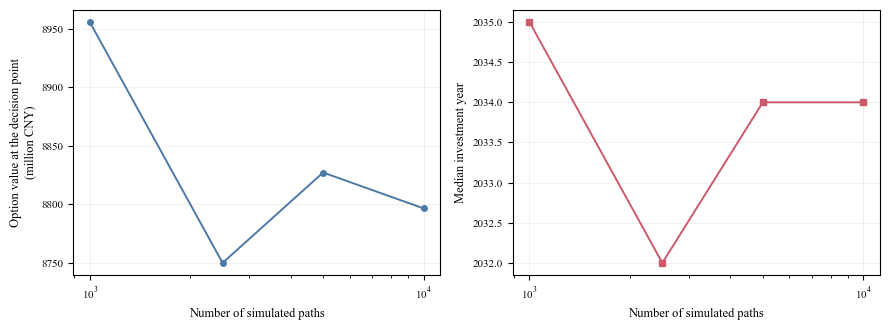

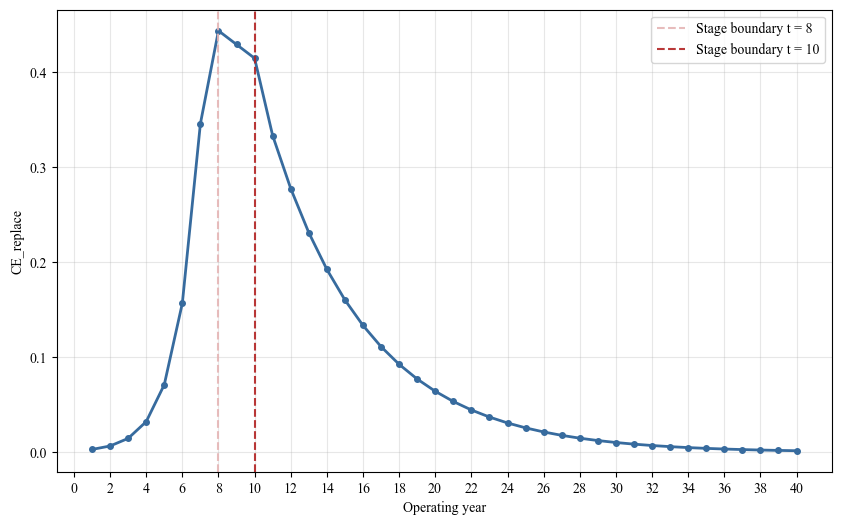

Initialising the CCUS investment decision model...
Model initialised: 
  Annual generation: 2,338,908,000 kWh
Electricity price model parameters:
  Initial electricity price: 0.350 CNY/kWh
  Long-run equilibrium price: 0.600 CNY/kWh
  Mean reversion speed: 0.4556
  Electricity price volatility: 0.100
  Correlation with the carbon price: 0.4
  Years in stage one: 5
  Annual CO2 capture: 1,604,023 t
  Annual CO2 injected for EOR: 1,604,023 t
  Annual generation loss: 748,450,560 kWh
  Risk-adjusted discount rate: 0.074
  Time structure: plant life 30 years = decision window 10 years + construction 1 year(s) + dynamic operating period
Simulating uncertainty paths...
Simulating electricity price paths...
Running the least-squares Monte Carlo solver...
Pre-computing the value matrices...
  value matrices: 1000/10000 paths priced
  value matrices: 2000/10000 paths priced
  value matrices: 3000/10000 paths priced
  value matrices: 4000/10000 paths priced
  value matrices: 5000/10000 paths pri

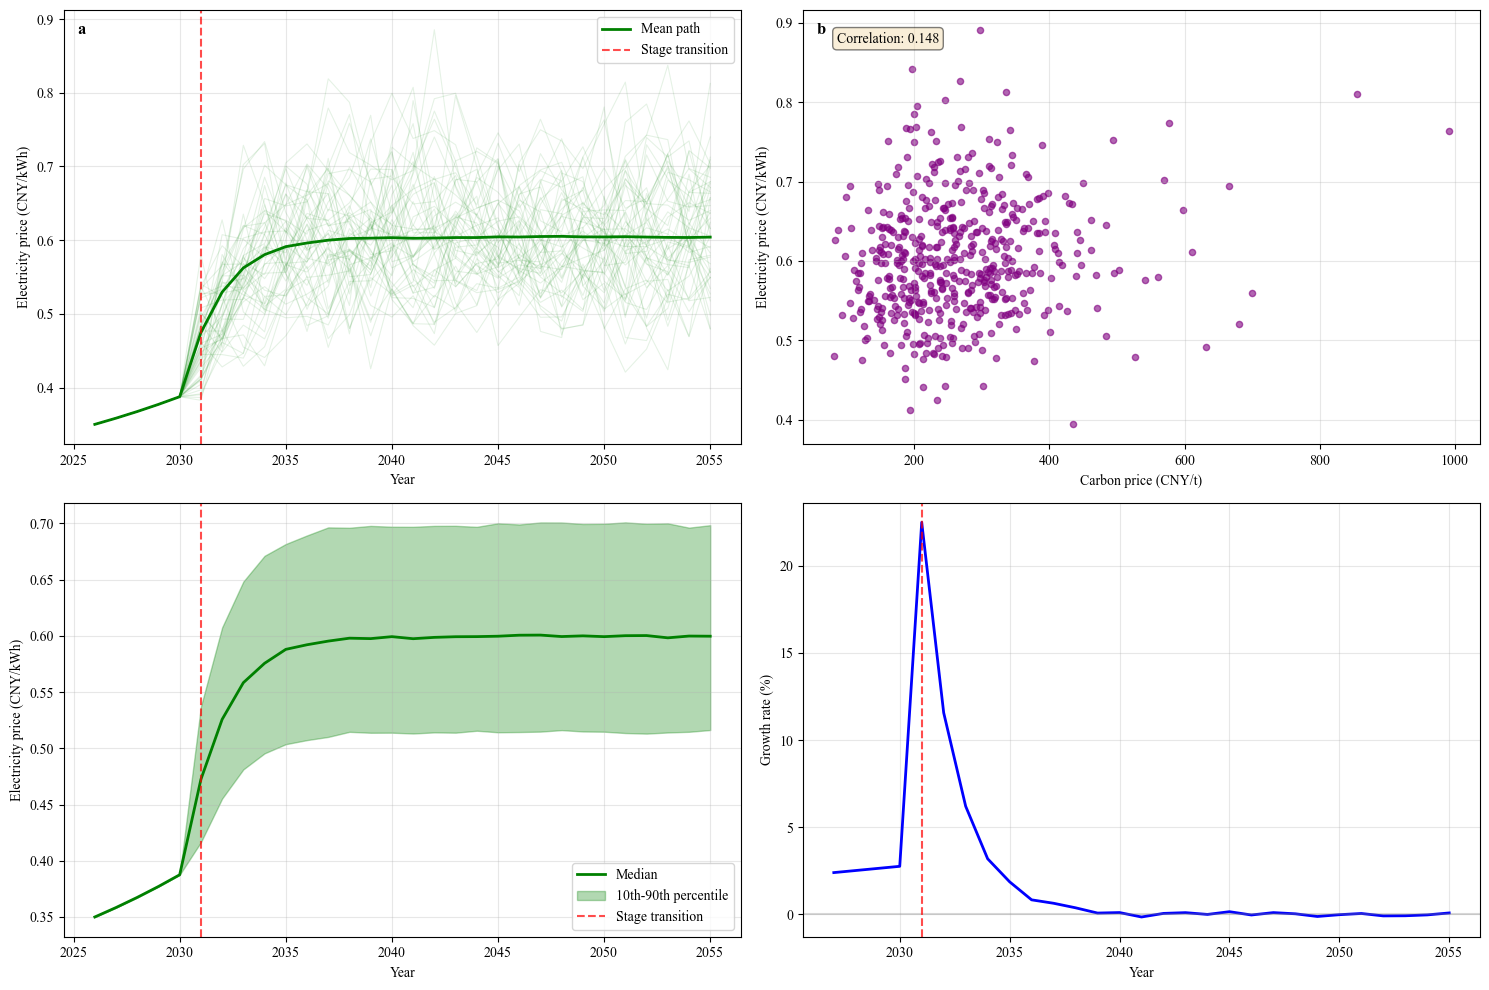

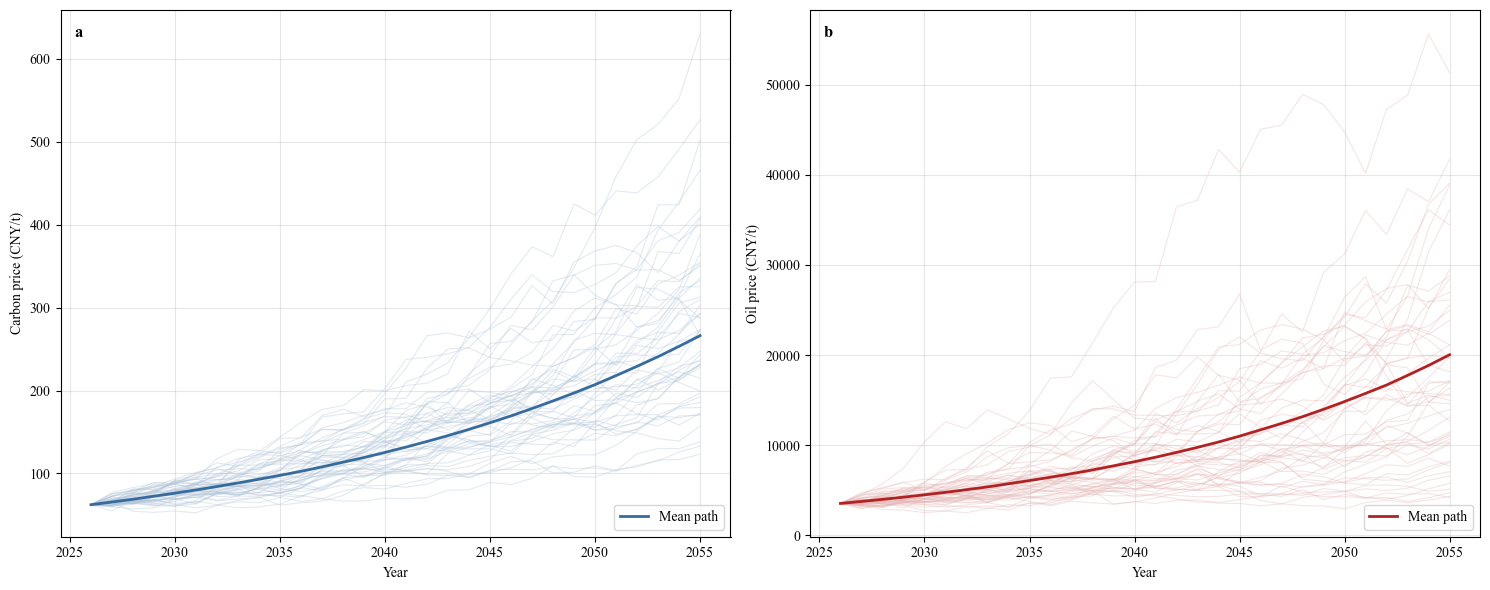

[figure] saved figures\c_distribution_of_optimal_investment_timing.png at 1000 dpi


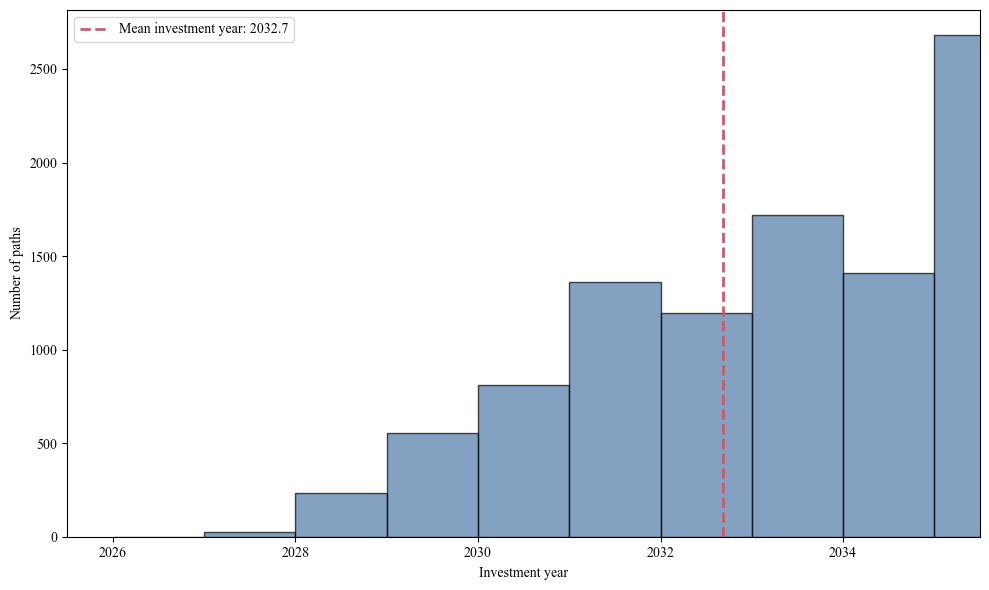


TIV statistics:
  Mean TIV: 12412.16 million CNY
  Max TIV: 125252.88 million CNY
  Min TIV: 62.32 million CNY
  Share of paths with positive TIV: 99.9%

Deferral option value statistics:
  Mean deferral option value: 1246.57 million CNY
  Max deferral option value: 20714.94 million CNY
  Share of paths with positive option value: 41.8%
  Option value as a share of total value: 4.2%
[figure] saved figures\f_distribution_of_the_deferral_option_value.png at 1000 dpi


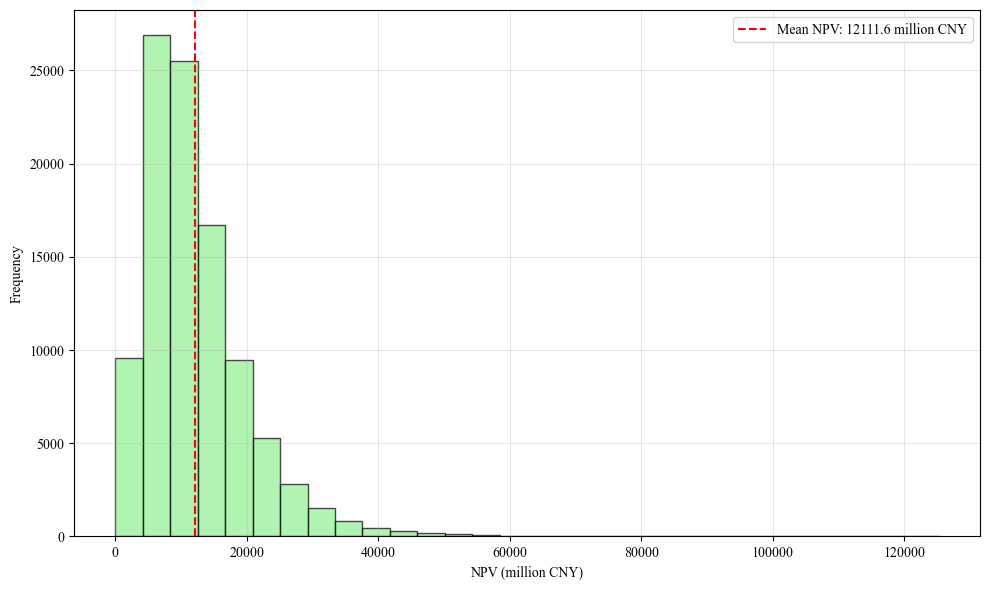

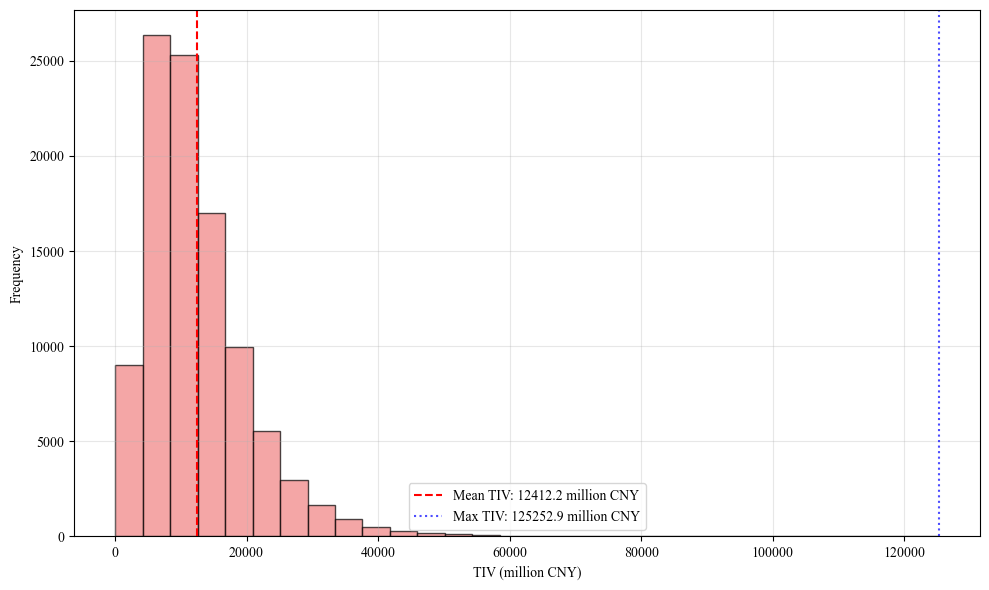

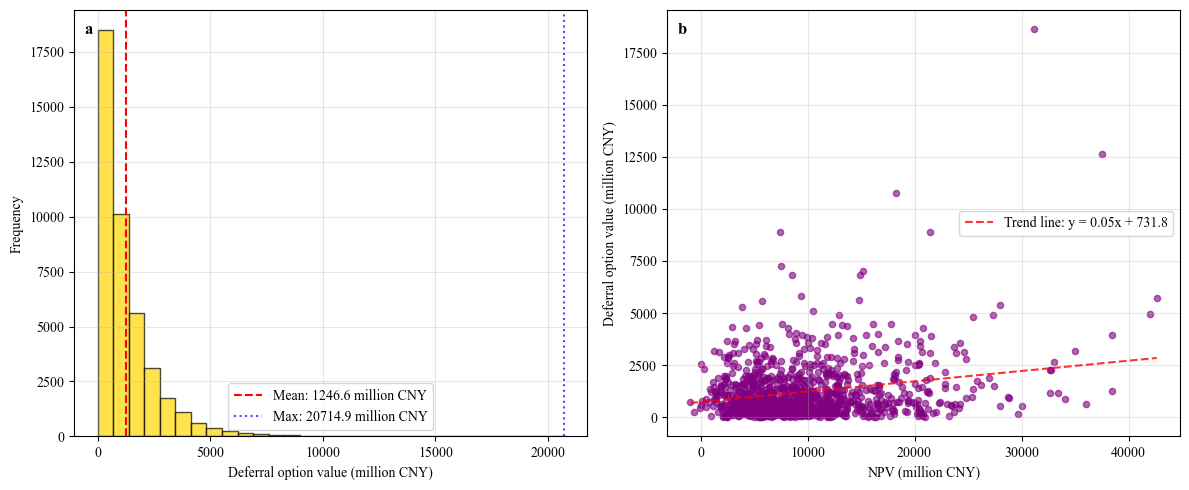

[figure] saved figures\i_investment_timing_and_investment_value.png at 1000 dpi


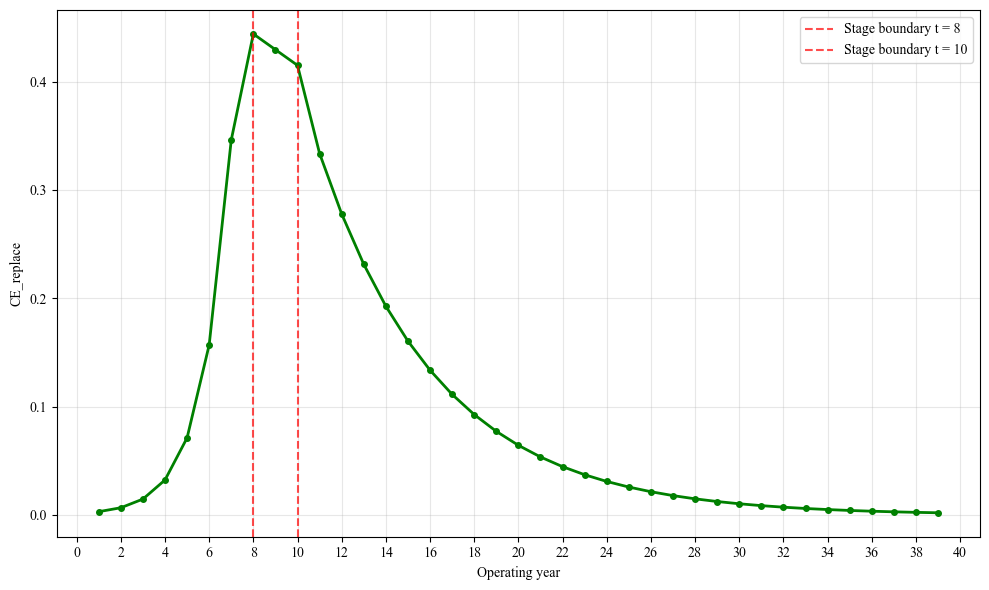

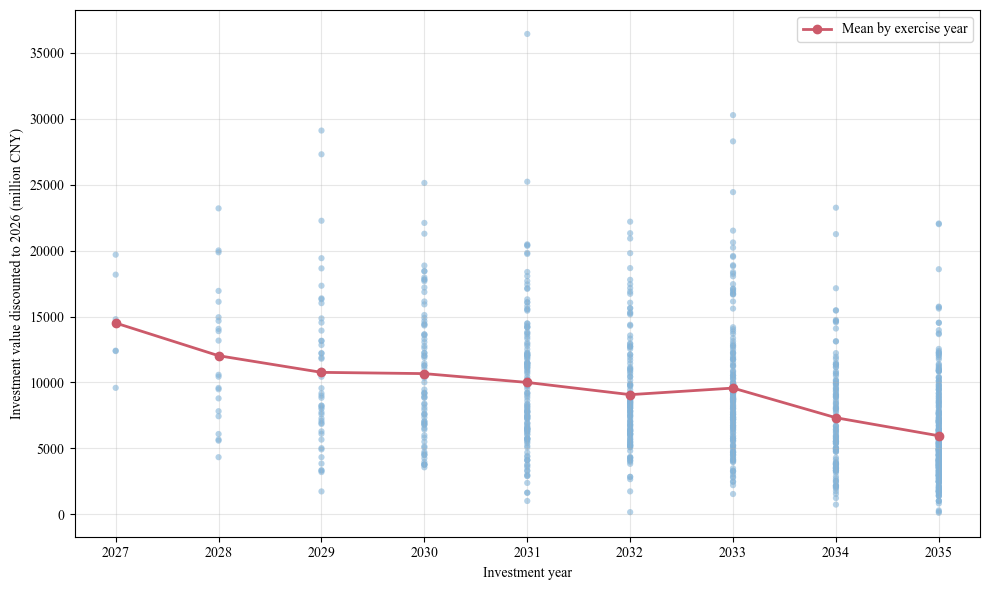

Show the detailed price statistics figures? -> y   [CCUS_NONINTERACTIVE]

=== Detailed price statistics ===
Carbon price statistics (year 30):
  Mean: 266.16 CNY/t
  Standard deviation: 104.26 CNY/t
  10th percentile: 151.61 CNY/t
  90th percentile: 401.42 CNY/t

Oil price statistics (year 30):
  Mean: 20037.91 CNY/t
  Standard deviation: 13102.13 CNY/t
  10th percentile: 7865.84 CNY/t
  90th percentile: 35921.53 CNY/t

=== Timing check ===
Plant life: 30 years (from 2026 to 2055 years)
Investment decision window: 10 years (from 2026 to 2035 years)
Construction period: 1 years

Timing implied by each investment year:
  Investment year 2026:
    - construction period: 2026-2027
    - operating period: 2027-2055 years (29 years)
    - project horizon: 2026-2055
  Investment year 2027:
    - construction period: 2027-2028
    - operating period: 2028-2055 years (28 years)
    - project horizon: 2027-2055
  Investment year 2028:
    - construction period: 2028-2029
    - operating period: 

31.5585820999695

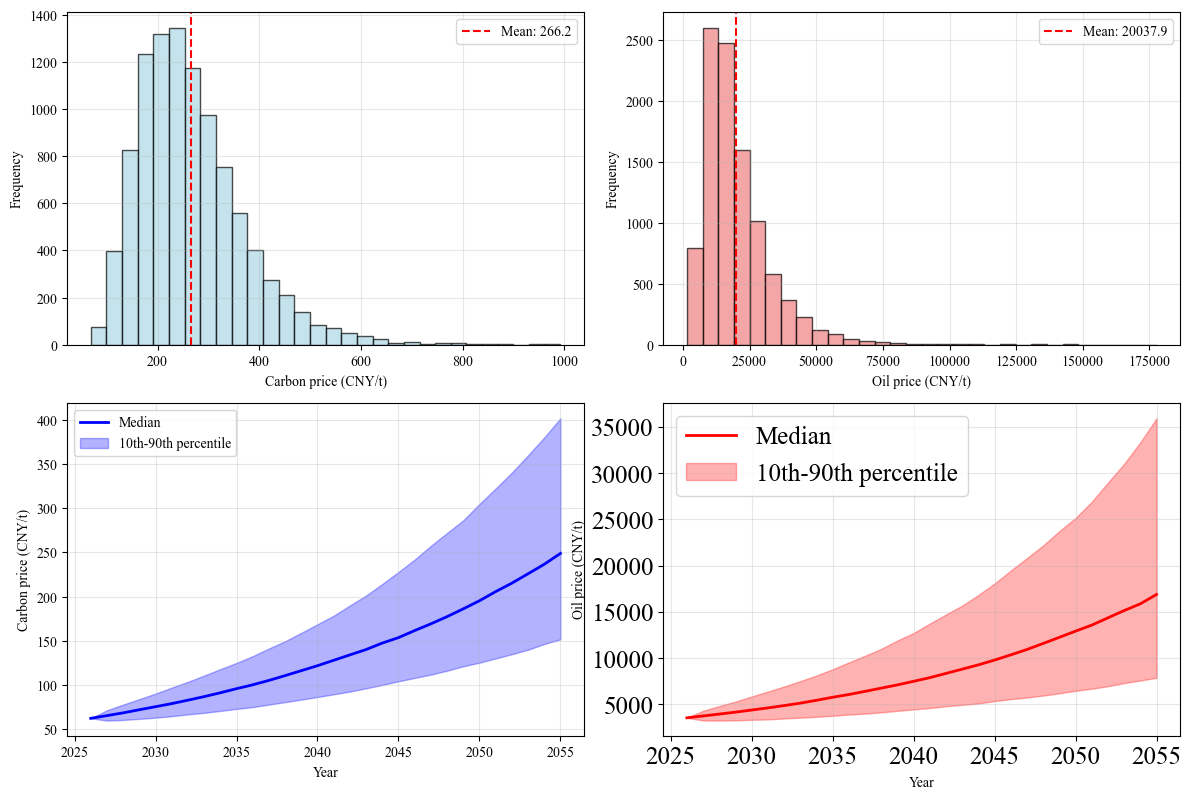

In [18]:
# ============ 1. 运行 ccus_part1.py：基准模型与主结果（论文 6.1 节、图2-图4） ============
if "run_script" not in globals():
    raise RuntimeError("请先运行上方第 0 个 cell（环境与工作目录设置）")
run_script("ccus_part1.py")


运行 ccus_part2senario.py
 Initialising the baseline CCUS model...
Model initialised: 
  Annual generation: 2,338,908,000 kWh
Electricity price model parameters:
  Initial electricity price: 0.350 CNY/kWh
  Long-run equilibrium price: 0.600 CNY/kWh
  Mean reversion speed: 0.4556
  Electricity price volatility: 0.100
  Correlation with the carbon price: 0.4
  Years in stage one: 5
  Annual CO2 capture: 1,604,023 t
  Annual CO2 injected for EOR: 1,604,023 t
  Annual generation loss: 748,450,560 kWh
  Risk-adjusted discount rate: 0.074
  Time structure: plant life 30 years = decision window 10 years + construction 1 year(s) + dynamic operating period
Simulating uncertainty paths...
Simulating electricity price paths...
Running the least-squares Monte Carlo solver...
Pre-computing the value matrices...
  value matrices: 1000/10000 paths priced
  value matrices: 2000/10000 paths priced
  value matrices: 3000/10000 paths priced
  value matrices: 4000/10000 paths priced
  value matrices: 5000/1

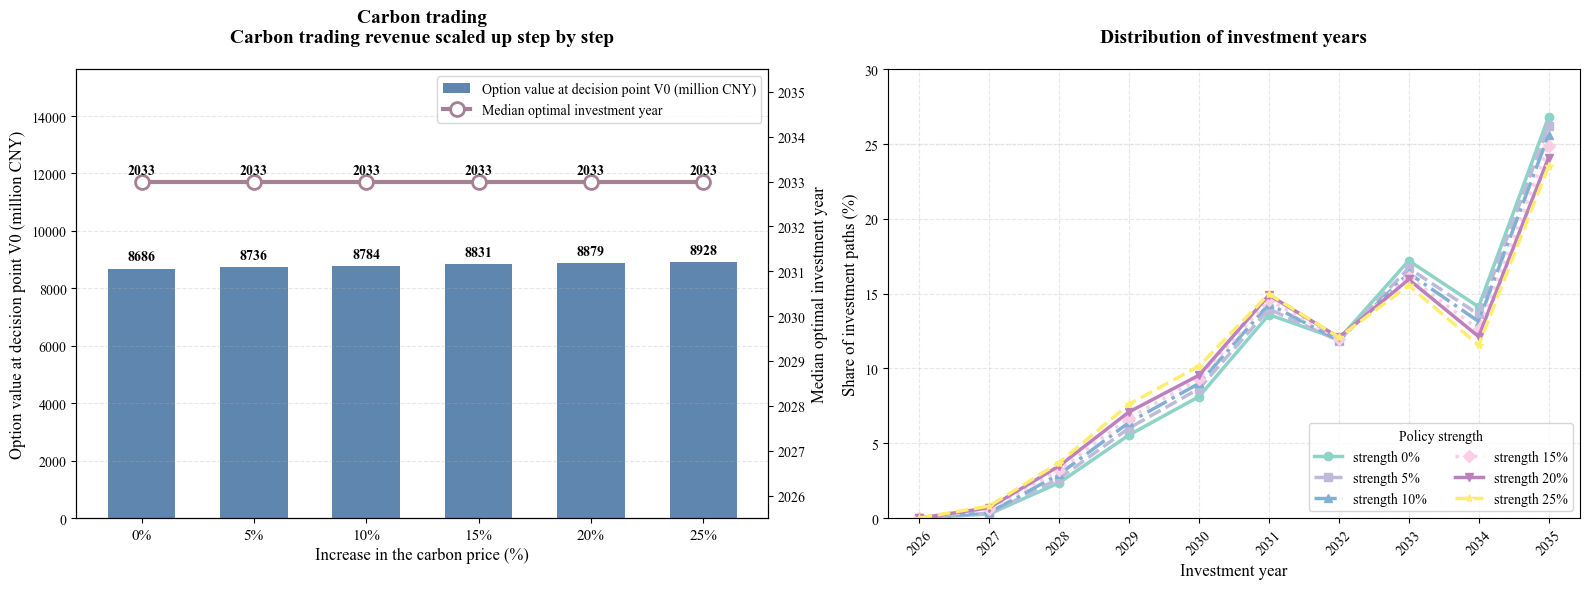


 Generating: One-off investment subsidy
 figure saved: figures\one_off_investment_subsidy_investment_subsidy_ratio_scaled_u.png


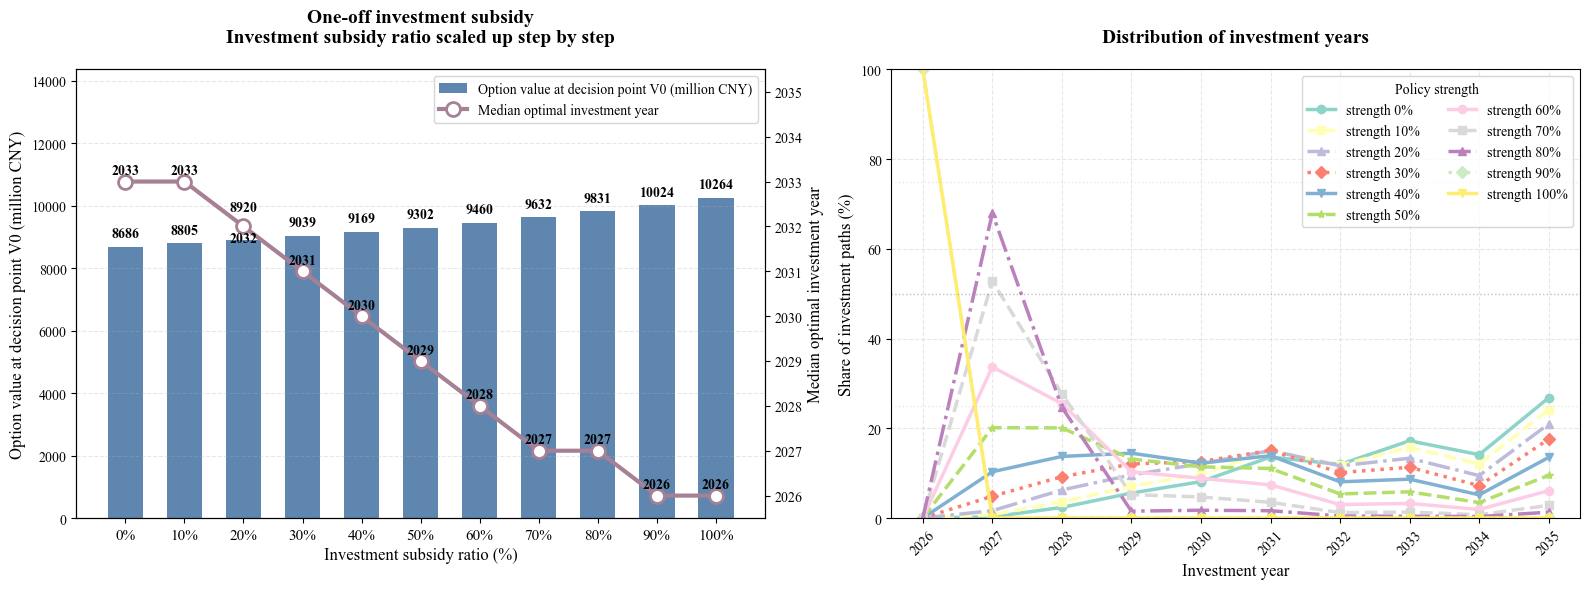


 Generating: Technology incentives
 figure saved: figures\technology_incentives_45q_utilisation_credit_scaled_up_from_.png


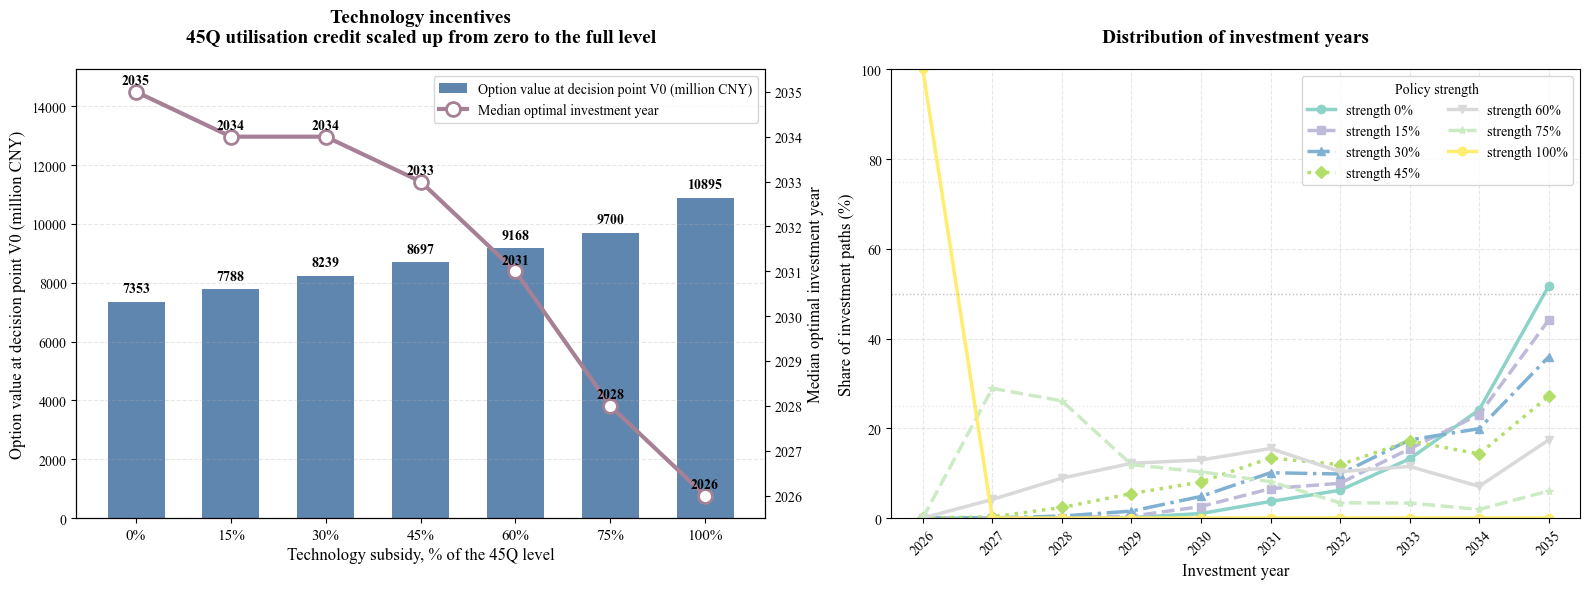


 Generating: Tax incentives
 figure saved: figures\tax_incentives_tax_relief_scaled_up_step_by_step.png


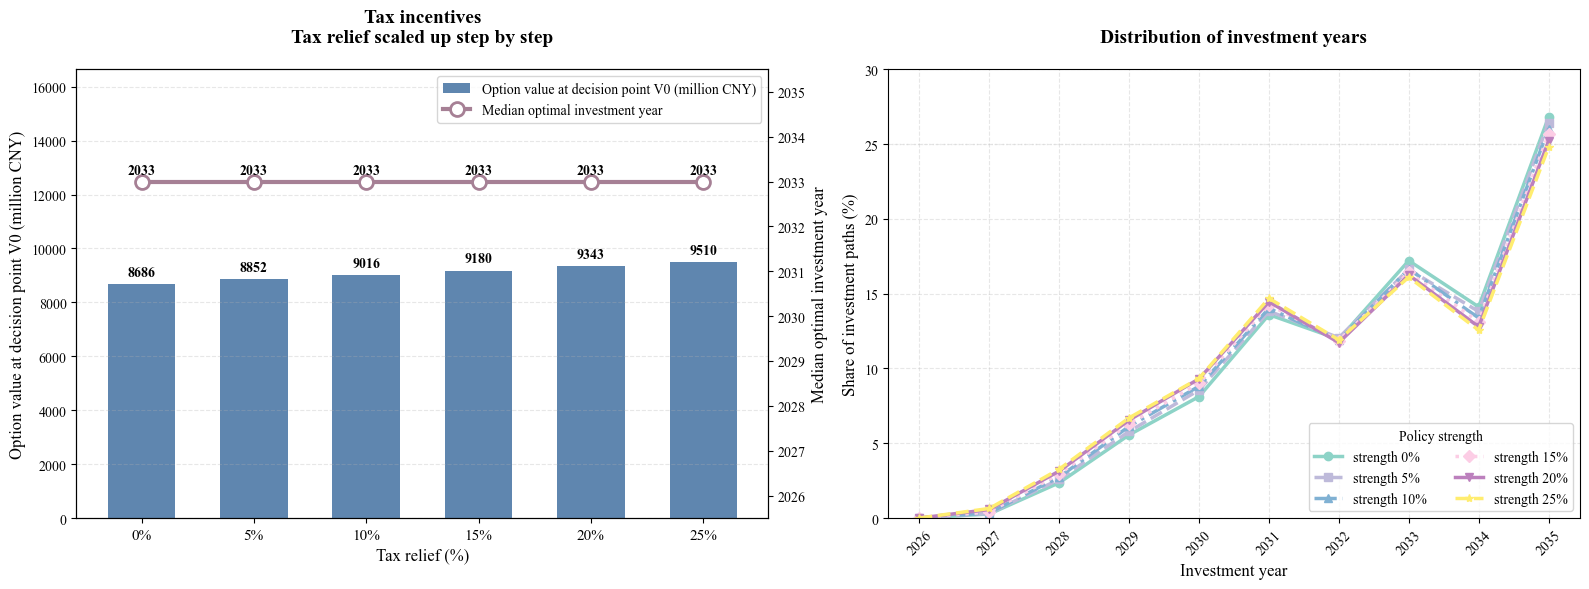


 Generating: Combined policy: carbon trading + one-off investment subsidy
 figure saved: figures\combo_carbon_subsidy_policy_intensity.png


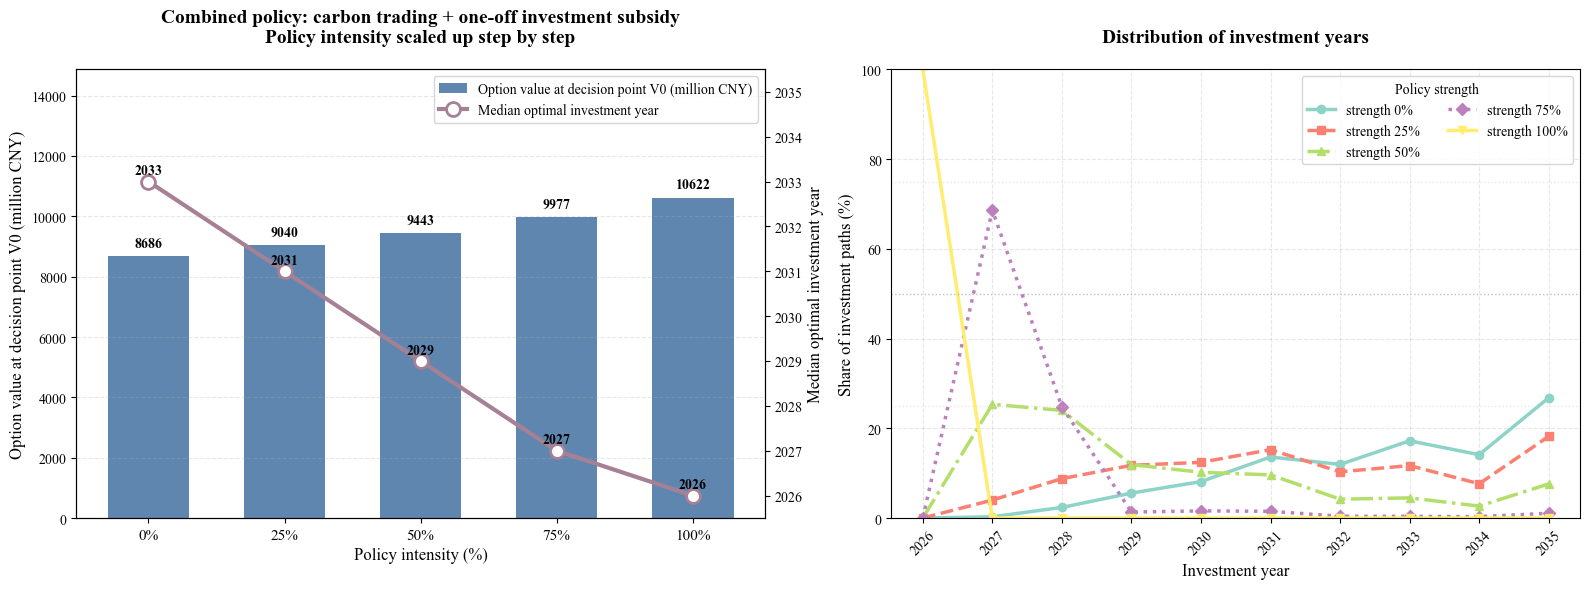


 Generating: Combined policy: carbon trading + tax incentives
 figure saved: figures\combo_carbon_tax_policy_intensity.png


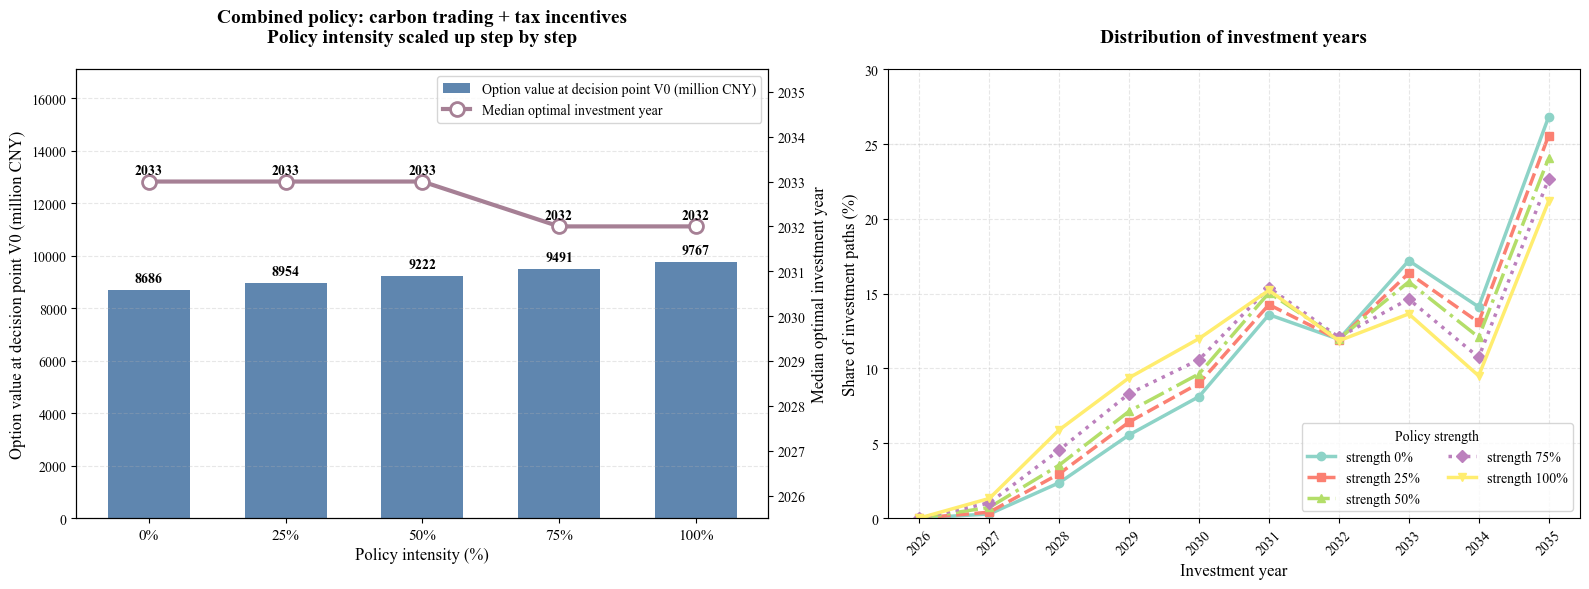


 Generating: Combined policy: carbon trading + technology incentives
 figure saved: figures\combo_carbon_technology_policy_intensity.png


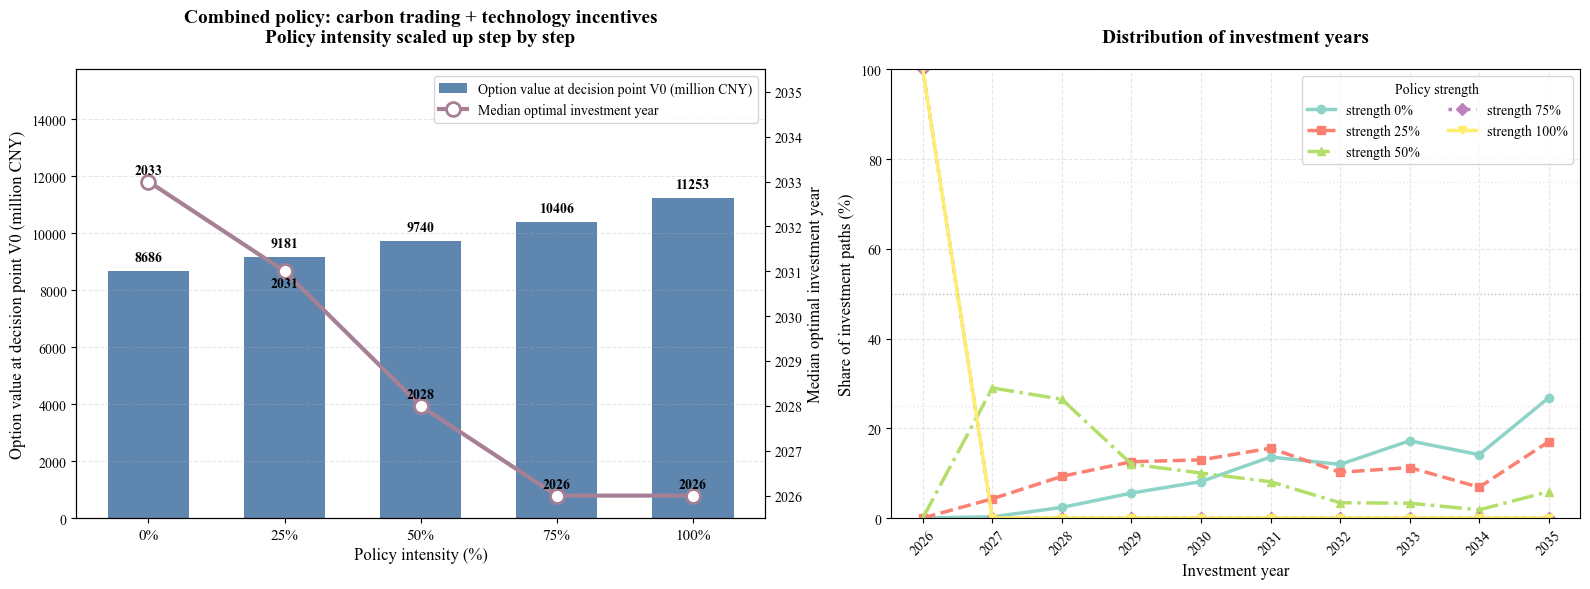


 Generating: Combined policy: one-off investment subsidy + tax incentives
 figure saved: figures\combo_subsidy_tax_policy_intensity.png


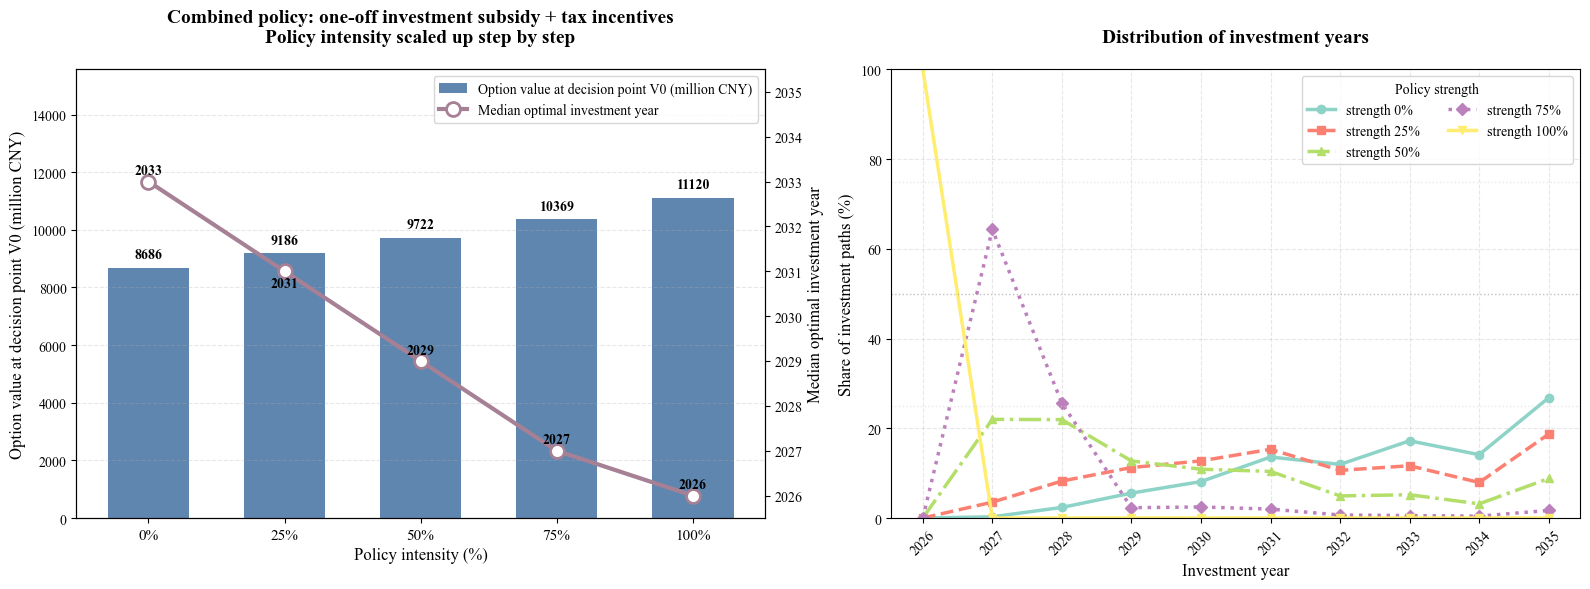


 Generating: Combined policy: one-off investment subsidy + technology incentives
 figure saved: figures\combo_subsidy_technology_policy_intensity.png


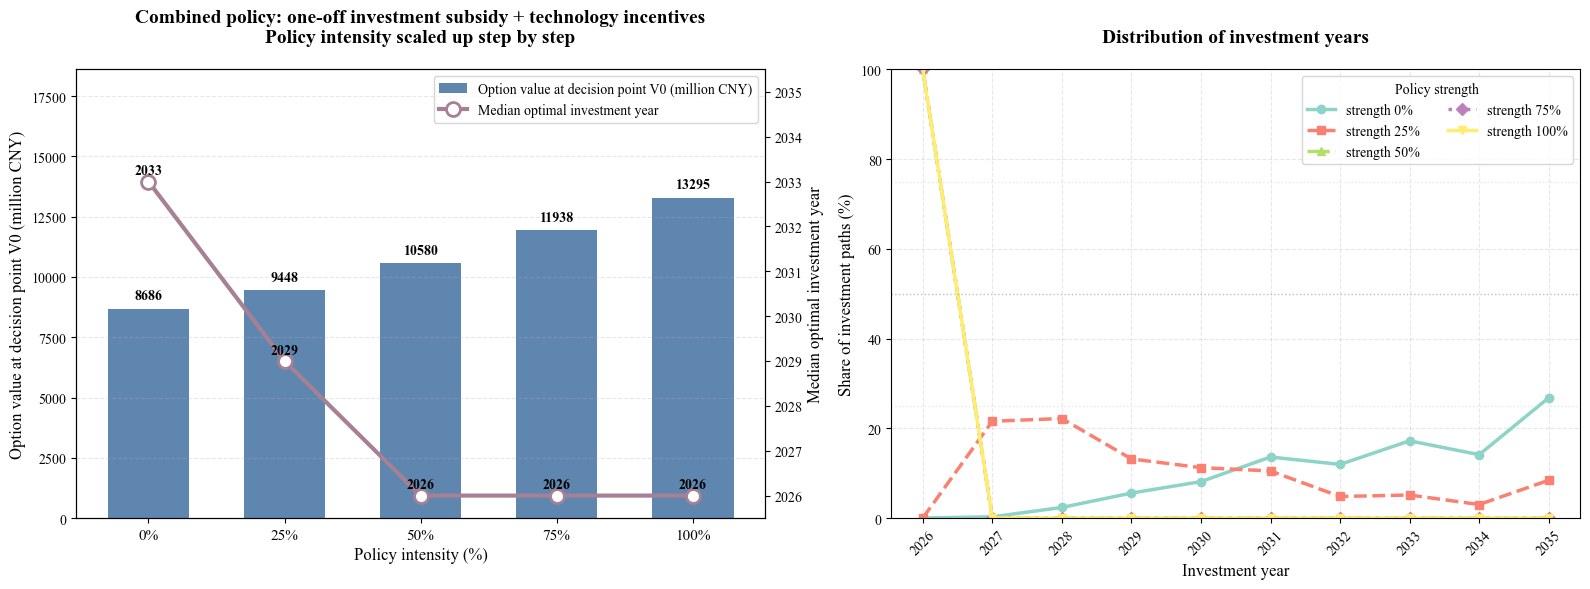


 Generating: Combined policy: tax incentives + technology incentives
 figure saved: figures\combo_tax_technology_policy_intensity.png


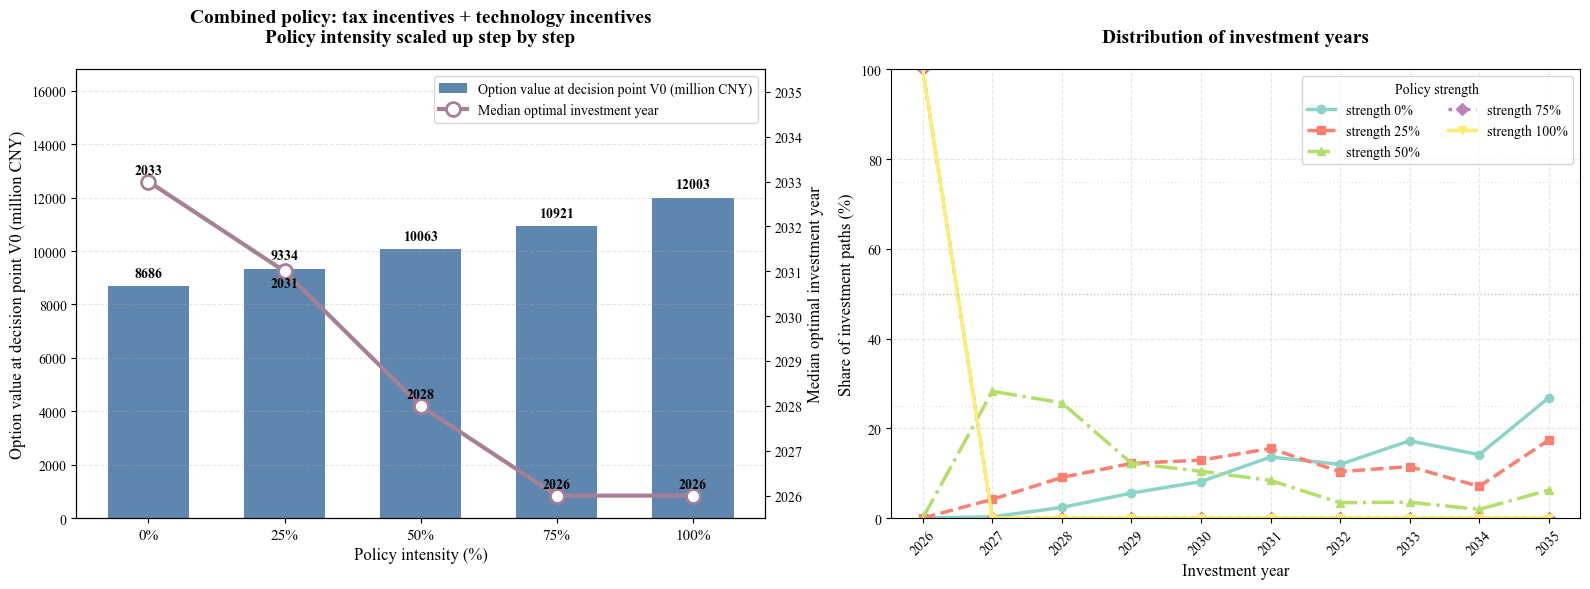


 Generating: Combined policy: carbon trading + one-off investment subsidy + tax incentives
 figure saved: figures\combo_carbon_subsidy_tax_policy_intensity.png


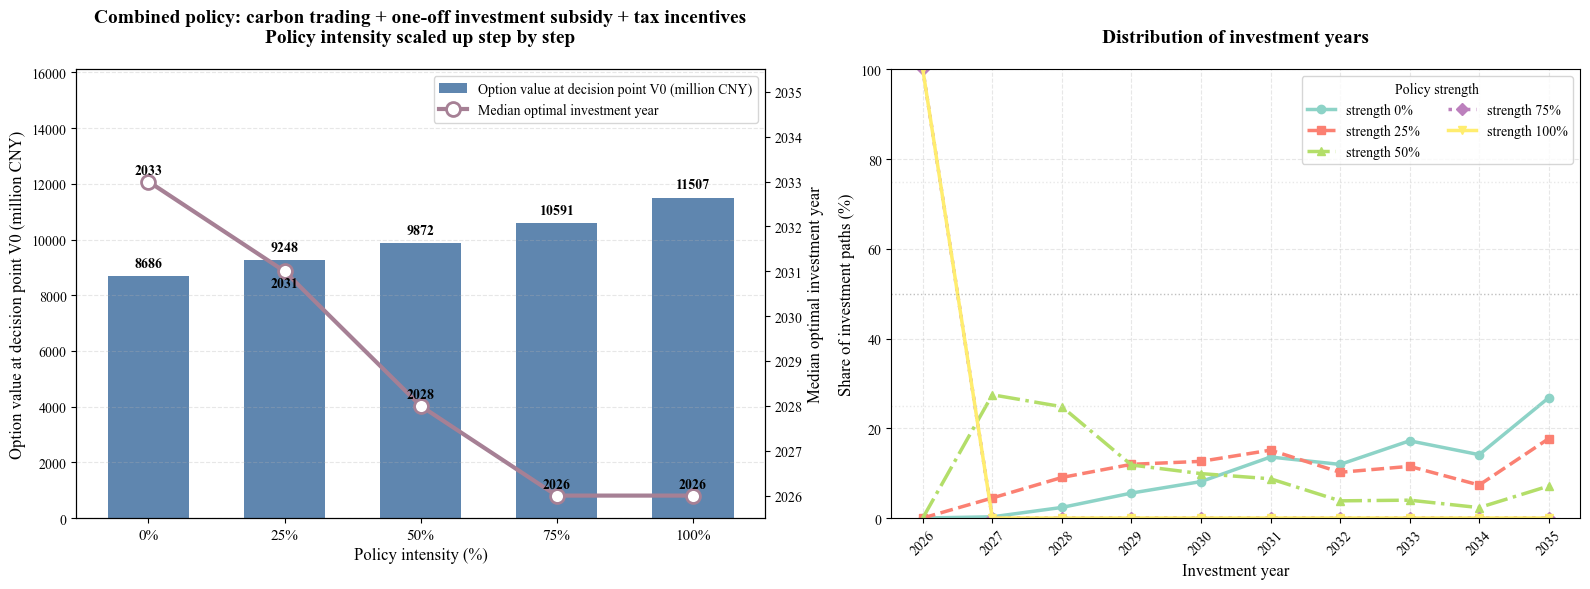


 Generating: Combined policy: carbon trading + one-off investment subsidy + technology incentives
 figure saved: figures\combo_carbon_subsidy_technology_policy_intensity.png


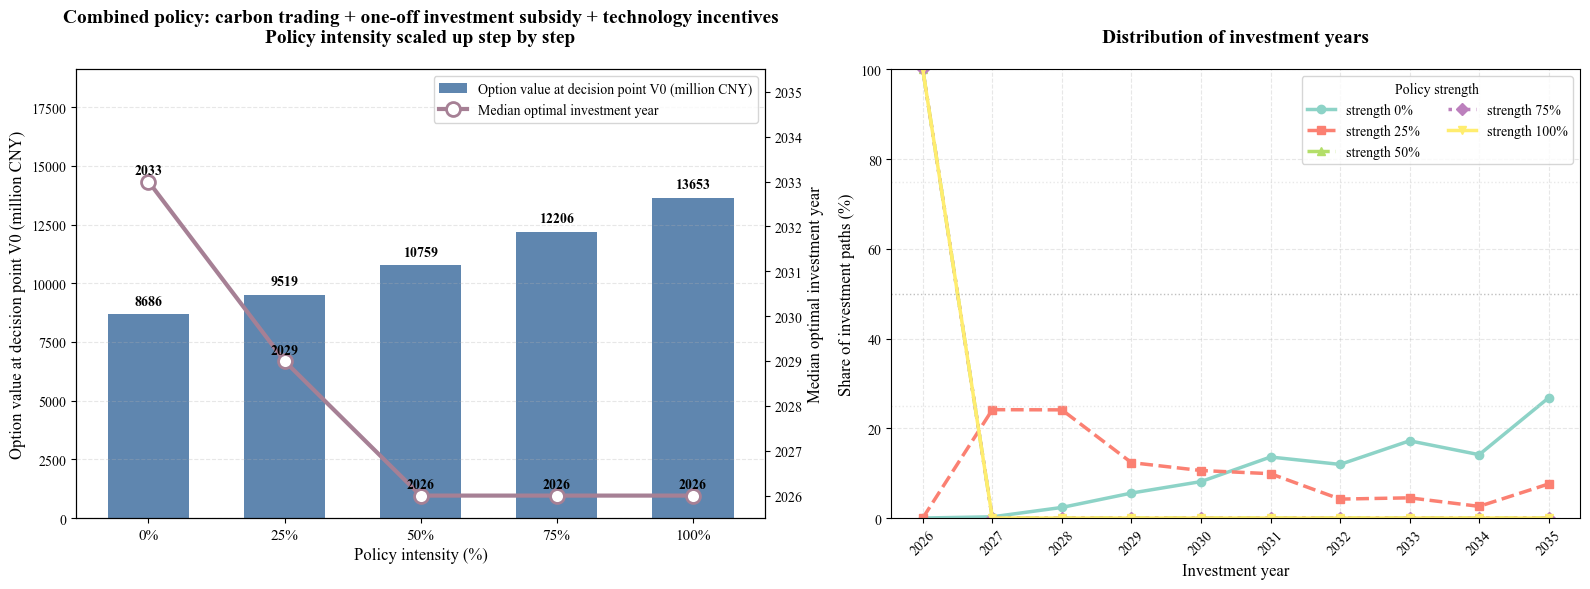


 Generating: Combined policy: carbon trading + tax incentives + technology incentives
 figure saved: figures\combo_carbon_tax_technology_policy_intensity.png


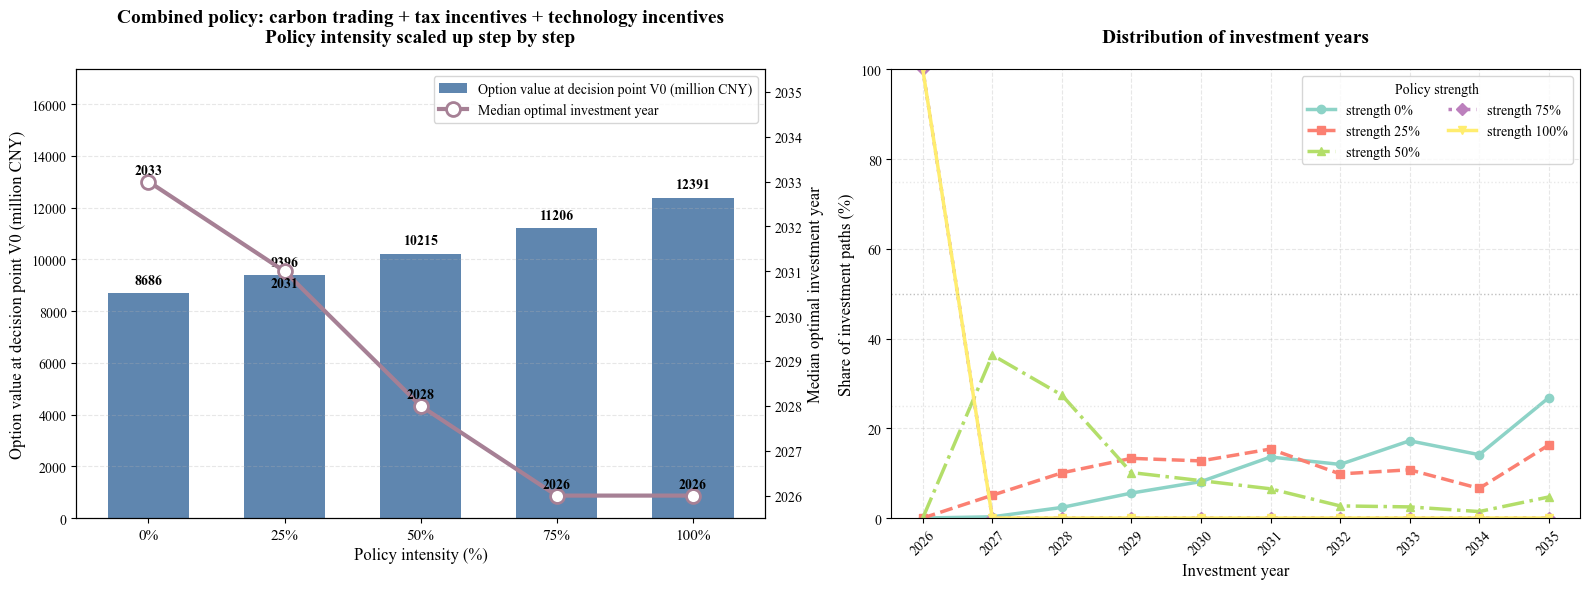


 Generating: Combined policy: one-off investment subsidy + tax incentives + technology incentives
 figure saved: figures\combo_subsidy_tax_technology_policy_intensity.png


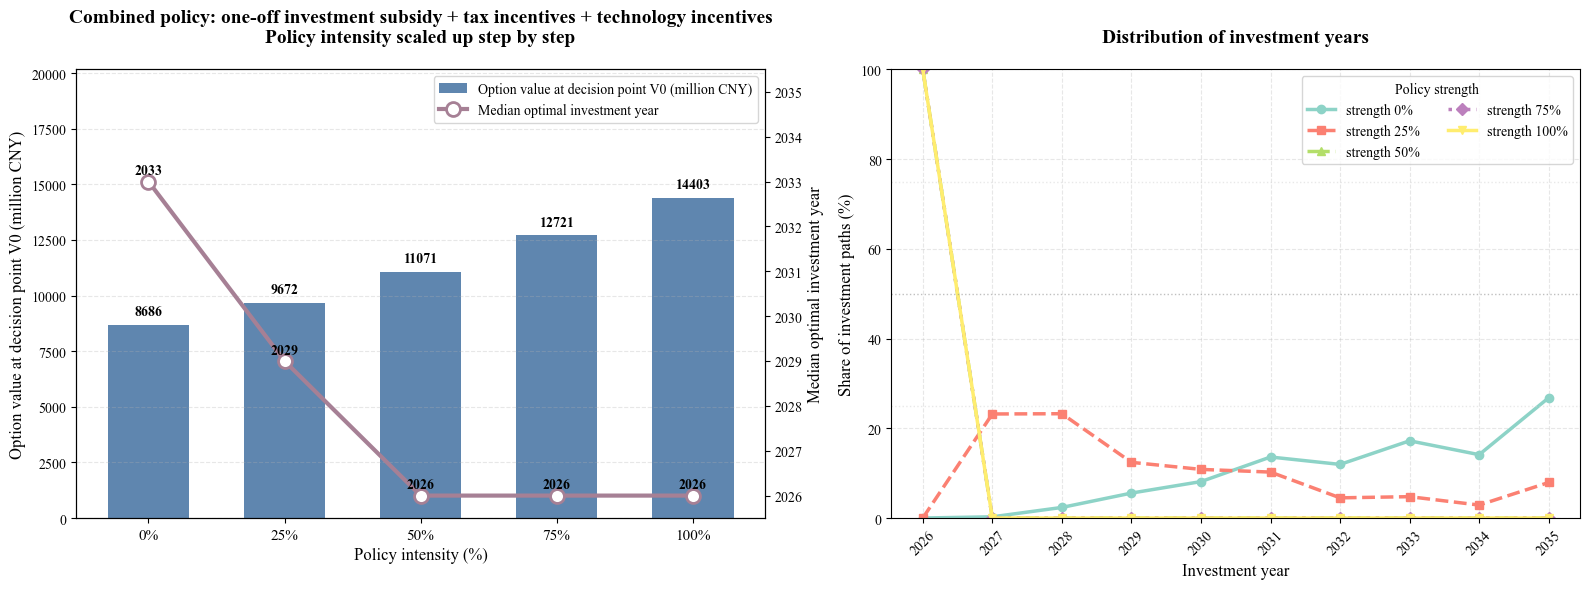


 Generating: Combined policy: carbon trading + one-off investment subsidy + tax incentives + technology incentives
 figure saved: figures\combo_carbon_subsidy_tax_technology_policy_intensity.png


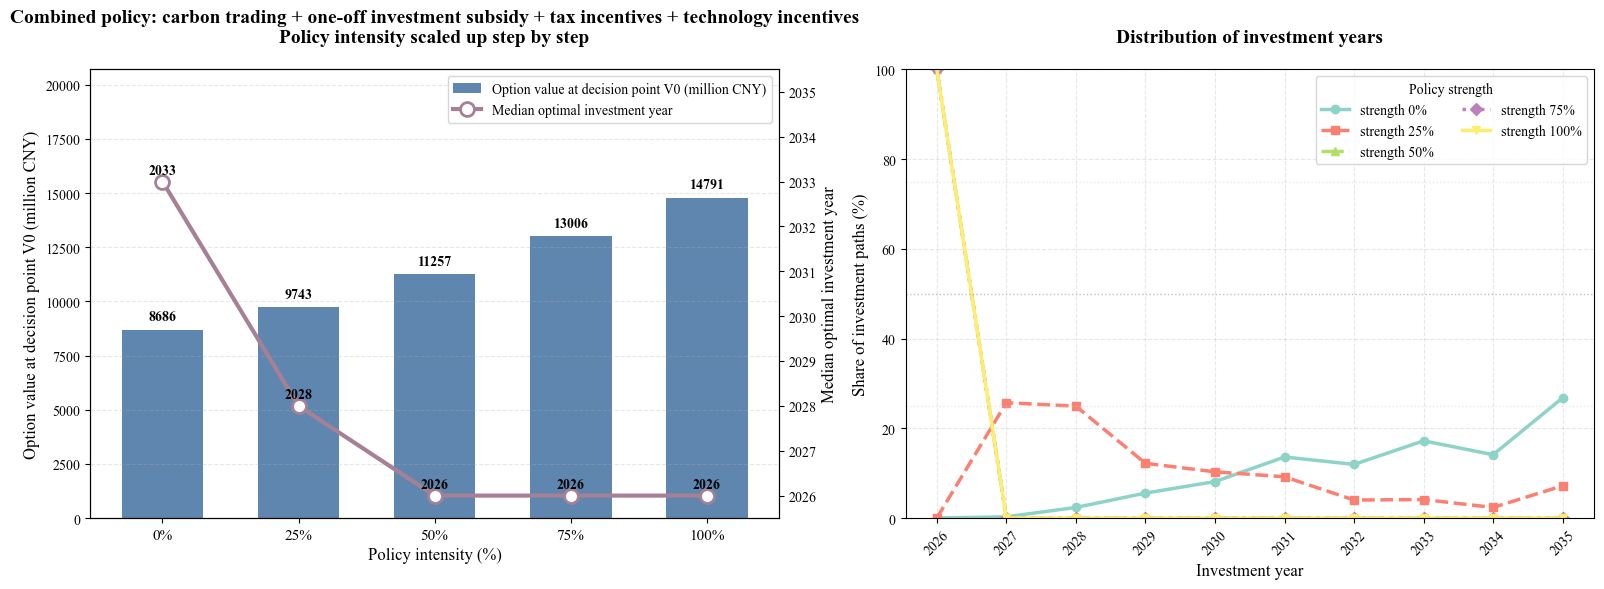


 All scenario figures generated.

 Plotting the scenario comparison
[figure] saved figures\optimal_investment_timing_across_policy_scenarios.png at 1000 dpi


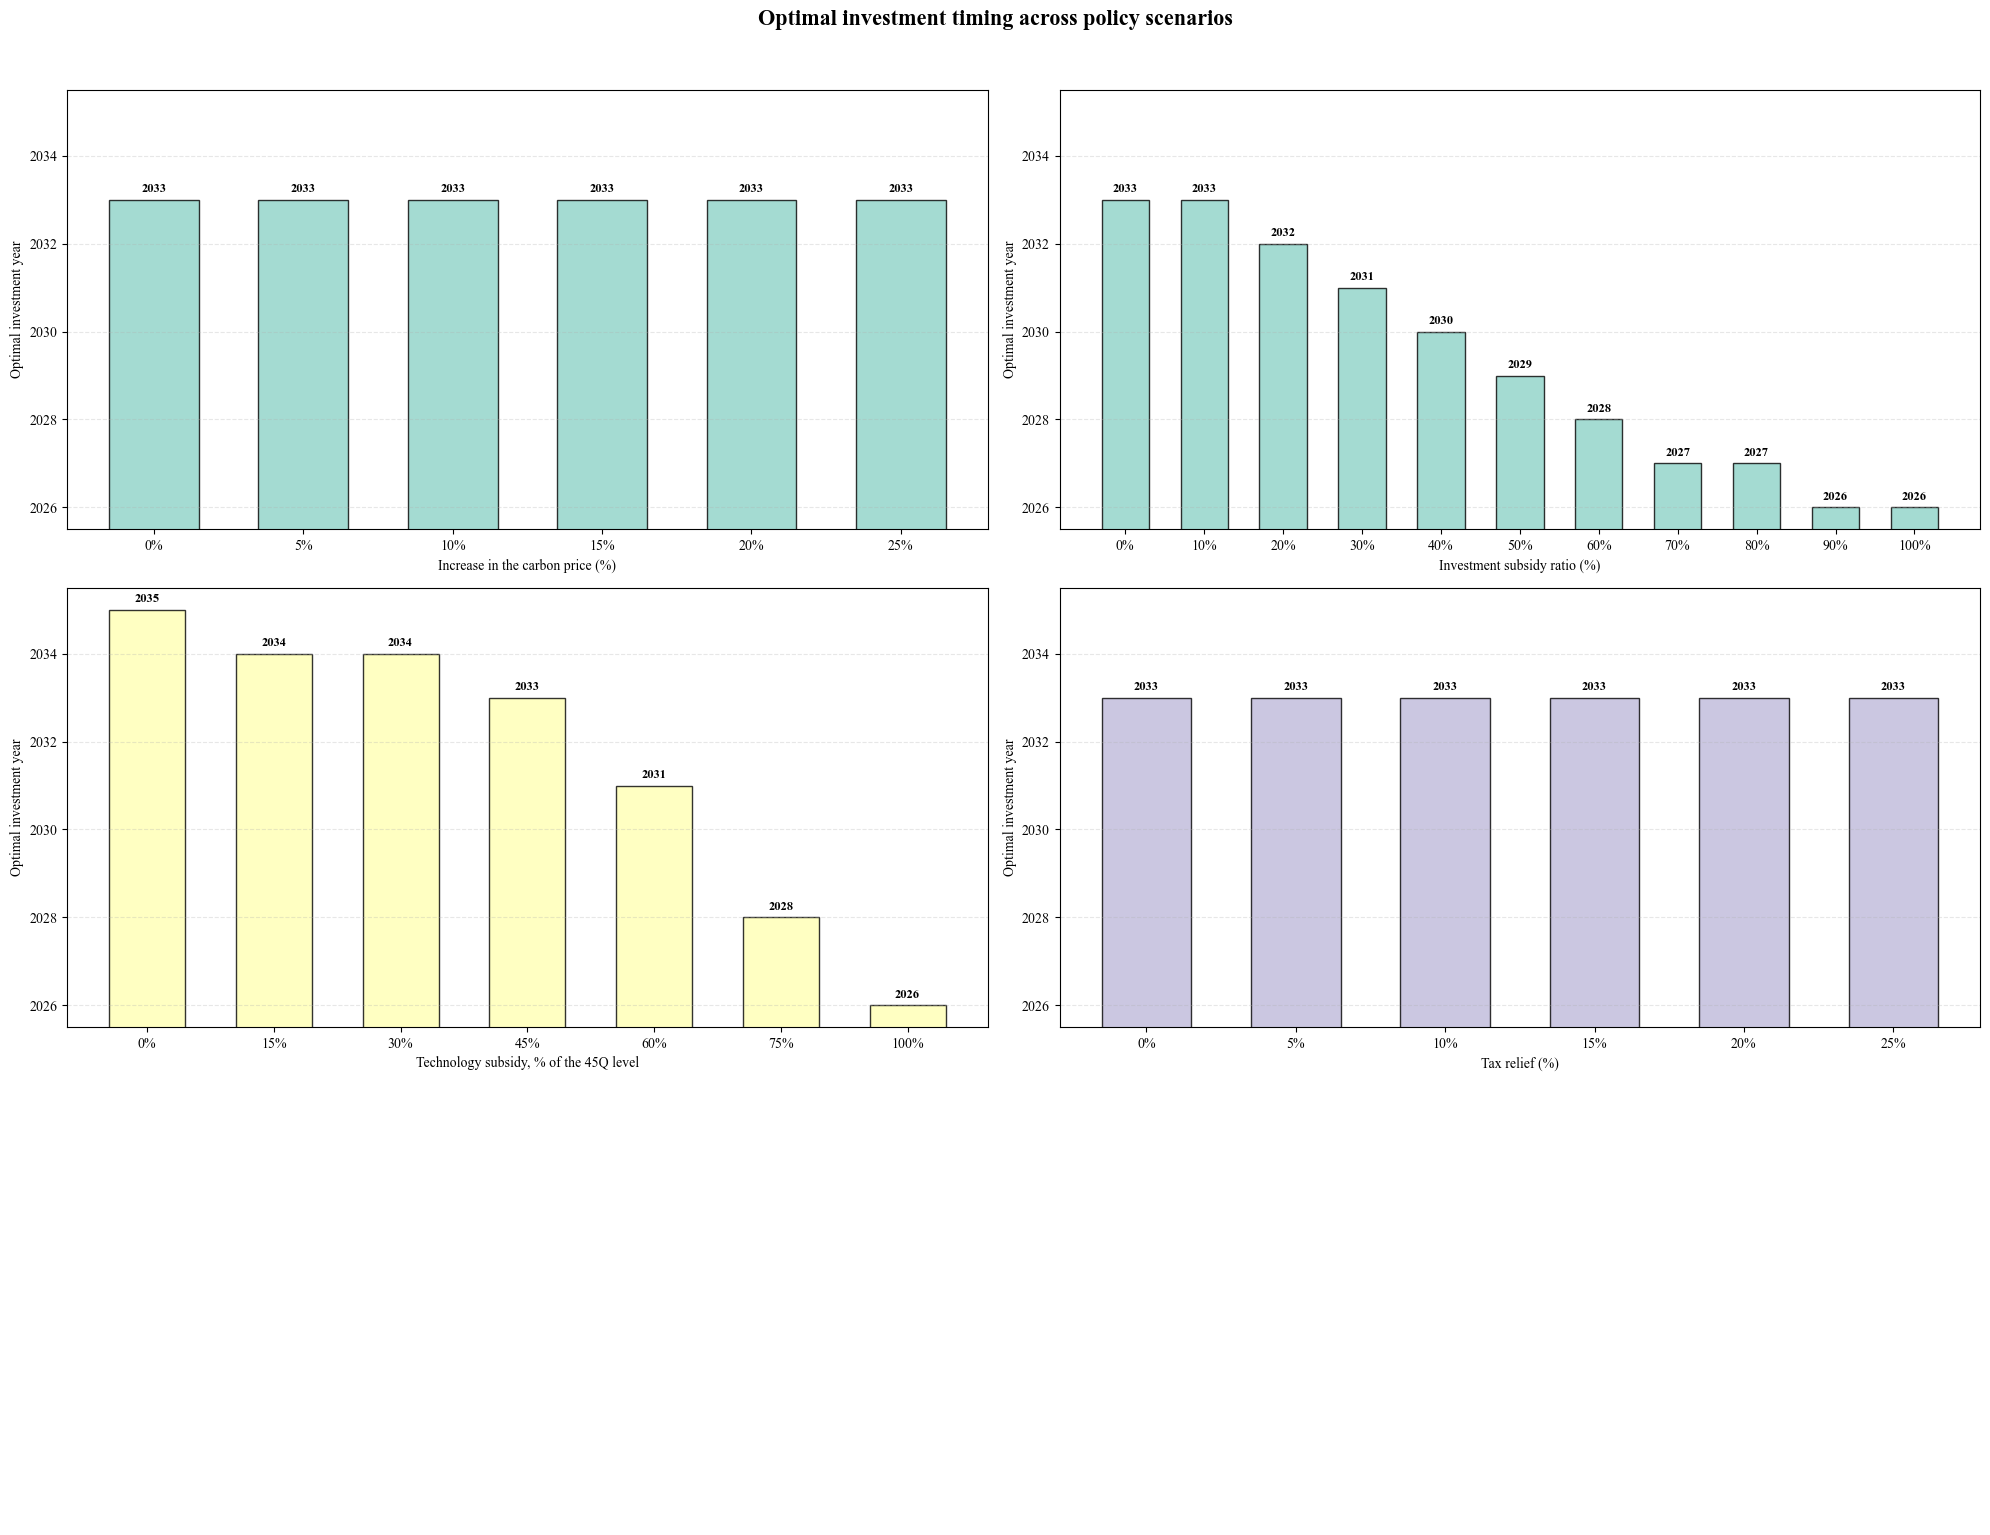


 Scenario analysis completed
 Summary of policy scenarios:
1. Carbon trading: raises the carbon price and shifts investment timing
2. One-off investment subsidy: lowers the initial investment cost
3. Technology incentives: raise subsidy revenue during operation
4. Tax incentives: lower the tax burden and raise net returns
5. On-grid electricity price: raises generation revenue
6. Initial oil price: affects EOR revenue
7. Combined policy scenarios: 3-way packages (11 scenarios, each at policy intensity [0.0, 0.25, 0.5, 0.75, 1.0])
[完成] ccus_part2senario.py 用时 1906.3 秒；本次新增图片 0 张，figures/ 共 34 张


1906.3312251000898

In [2]:
# ============ 2. 运行 ccus_part2senario.py：政策情景（论文 5.2、6.2 节，表4、图5） ============
if "run_script" not in globals():
    raise RuntimeError("请先运行上方第 0 个 cell（环境与工作目录设置）")
run_script("ccus_part2senario.py")


运行 ccus_part3.py
=== Sensitivity analysis of the CCUS investment decision model ===

Running the sensitivity analysis...
Running the sensitivity analysis...

Analysing parameter: alpha


  0%|          | 0/10 [00:00<?, ?it/s]

Model initialised: 
  Annual generation: 2,338,908,000 kWh
Electricity price model parameters:
  Initial electricity price: 0.350 CNY/kWh
  Long-run equilibrium price: 0.600 CNY/kWh
  Mean reversion speed: 0.4556
  Electricity price volatility: 0.100
  Correlation with the carbon price: 0.4
  Years in stage one: 5
  Annual CO2 capture: 1,604,023 t
  Annual CO2 injected for EOR: 1,604,023 t
  Annual generation loss: 748,450,560 kWh
  Risk-adjusted discount rate: 0.074
  Time structure: plant life 30 years = decision window 10 years + construction 1 year(s) + dynamic operating period
Simulating uncertainty paths...
Simulating electricity price paths...
Running the least-squares Monte Carlo solver...
Pre-computing the value matrices...
  value matrices: 1000/10000 paths priced
  value matrices: 2000/10000 paths priced
  value matrices: 3000/10000 paths priced
  value matrices: 4000/10000 paths priced
  value matrices: 5000/10000 paths priced
  value matrices: 6000/10000 paths priced
  val

 10%|█         | 1/10 [00:22<03:19, 22.21s/it]

  value matrices: 10000/10000 paths priced
Final decision point: 10000 paths choose to invest
Processing decision point t=8 (year 2034)
Processing decision point t=7 (year 2033)
Processing decision point t=6 (year 2032)
Processing decision point t=5 (year 2031)
Processing decision point t=4 (year 2030)
Processing decision point t=3 (year 2029)
Processing decision point t=2 (year 2028)
Processing decision point t=1 (year 2027)
Processing decision point t=0 (year 2026)
Determining the optimal investment timing...

Investment decision statistics:
  2027: 59 paths (0.6%), operating period 28 years
  2028: 323 paths (3.2%), operating period 27 years
  2029: 642 paths (6.4%), operating period 26 years
  2030: 889 paths (8.9%), operating period 25 years
  2031: 1398 paths (14.0%), operating period 24 years
  2032: 1147 paths (11.5%), operating period 23 years
  2033: 1630 paths (16.3%), operating period 22 years
  2034: 1313 paths (13.1%), operating period 21 years
  2035: 2599 paths (26.0%),

...

 91%|█████████ | 10/11 [03:48<00:22, 22.92s/it]

  value matrices: 10000/10000 paths priced
Final decision point: 10000 paths choose to invest
Processing decision point t=8 (year 2034)
Processing decision point t=7 (year 2033)
Processing decision point t=6 (year 2032)
Processing decision point t=5 (year 2031)
Processing decision point t=4 (year 2030)
Processing decision point t=3 (year 2029)
Processing decision point t=2 (year 2028)
Processing decision point t=1 (year 2027)
Processing decision point t=0 (year 2026)
Determining the optimal investment timing...

Investment decision statistics:
  2027: 5349 paths (53.5%), operating period 28 years
  2028: 2311 paths (23.1%), operating period 27 years
  2029: 841 paths (8.4%), operating period 26 years
  2030: 442 paths (4.4%), operating period 25 years
  2031: 291 paths (2.9%), operating period 24 years
  2032: 195 paths (1.9%), operating period 23 years
  2033: 133 paths (1.3%), operating period 22 years
  2034: 94 paths (0.9%), operating period 21 years
  2035: 344 paths (3.4%), opera

100%|██████████| 11/11 [04:11<00:00, 22.84s/it]

  value matrices: 10000/10000 paths priced
Final decision point: 10000 paths choose to invest
Processing decision point t=8 (year 2034)
Processing decision point t=7 (year 2033)
Processing decision point t=6 (year 2032)
Processing decision point t=5 (year 2031)
Processing decision point t=4 (year 2030)
Processing decision point t=3 (year 2029)
Processing decision point t=2 (year 2028)
Processing decision point t=1 (year 2027)
Processing decision point t=0 (year 2026)
Determining the optimal investment timing...

Investment decision statistics:
  2027: 5815 paths (58.1%), operating period 28 years
  2028: 2196 paths (22.0%), operating period 27 years
  2029: 756 paths (7.6%), operating period 26 years
  2030: 358 paths (3.6%), operating period 25 years
  2031: 234 paths (2.3%), operating period 24 years
  2032: 173 paths (1.7%), operating period 23 years
  2033: 100 paths (1.0%), operating period 22 years
  2034: 79 paths (0.8%), operating period 21 years
  2035: 289 paths (2.9%), opera

Running the least-squares Monte Carlo solver...
Pre-computing the value matrices...
  value matrices: 1000/10000 paths priced
  value matrices: 2000/10000 paths priced
  value matrices: 3000/10000 paths priced
  value matrices: 4000/10000 paths priced
  value matrices: 5000/10000 paths priced
  value matrices: 6000/10000 paths priced
  value matrices: 7000/10000 paths priced
  value matrices: 8000/10000 paths priced
  value matrices: 9000/10000 paths priced
  value matrices: 10000/10000 paths priced
Final decision point: 10000 paths choose to invest
Processing decision point t=8 (year 2034)
Processing decision point t=7 (year 2033)
Processing decision point t=6 (year 2032)
Processing decision point t=5 (year 2031)
Processing decision point t=4 (year 2030)
Processing decision point t=3 (year 2029)
Processing decision point t=2 (year 2028)
Processing decision point t=1 (year 2027)
Processing decision point t=0 (year 2026)
Determining the optimal investment timing...

Investment decision 

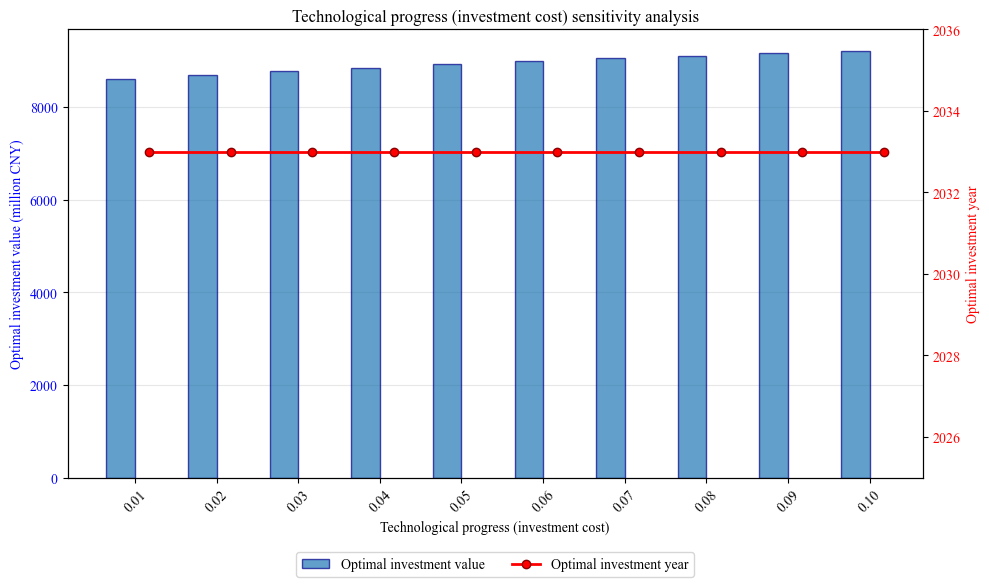

[figure] saved figures\technological_progress_o_m_cost_sensitivity_analysis.png at 1000 dpi


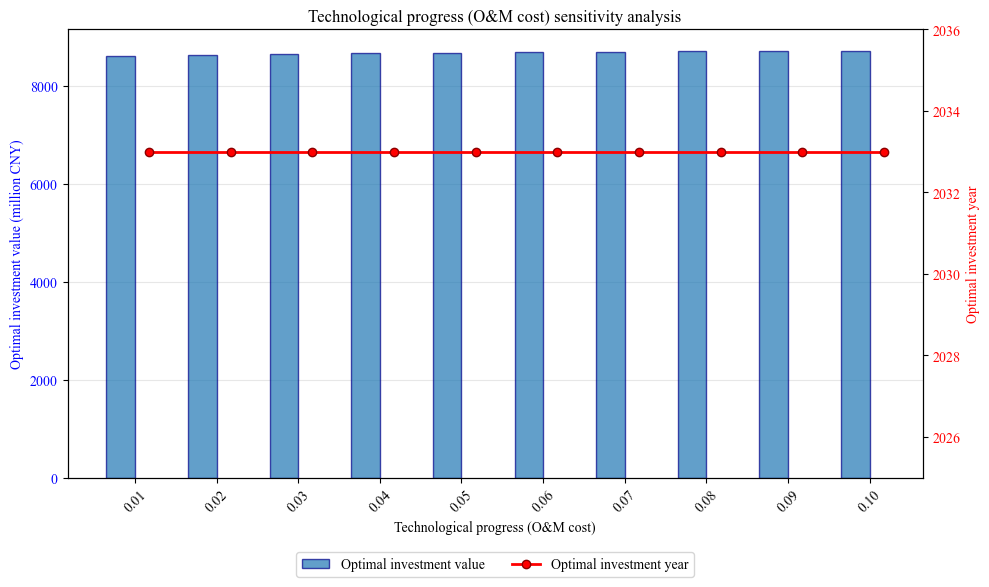

[figure] saved figures\initial_carbon_price_sensitivity_analysis.png at 1000 dpi


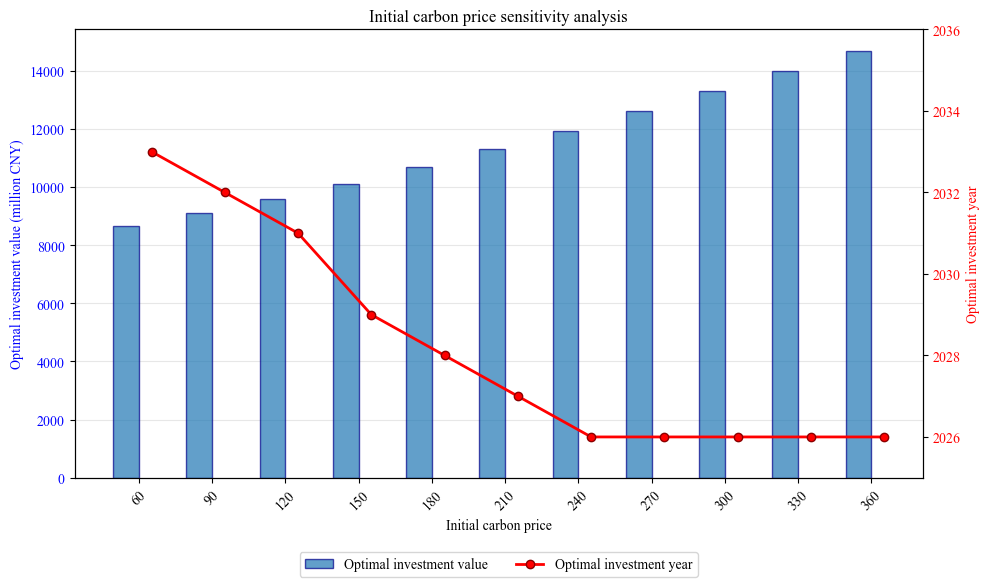

[figure] saved figures\carbon_price_drift_sensitivity_analysis.png at 1000 dpi


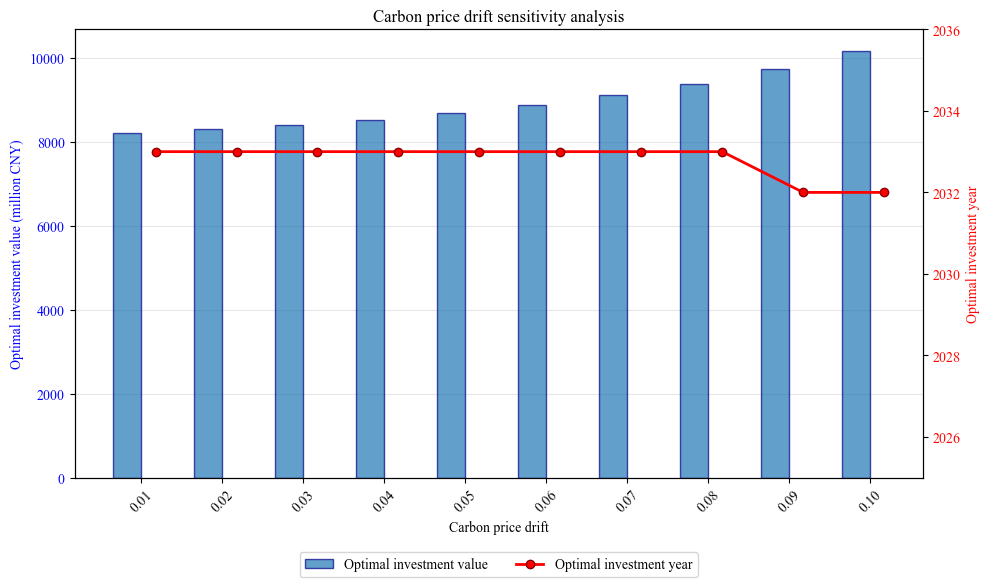

[figure] saved figures\carbon_price_volatility_sensitivity_analysis.png at 1000 dpi


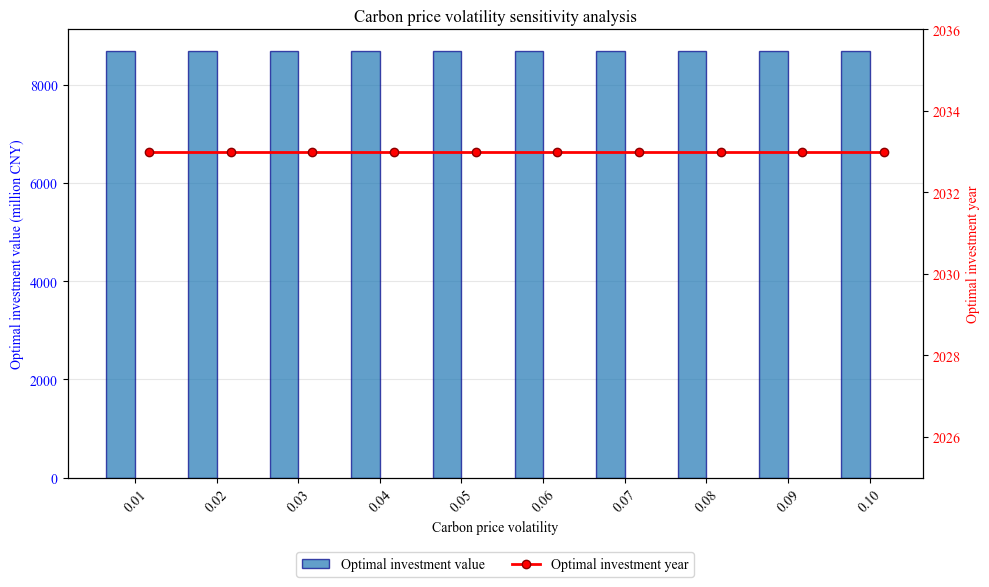

[figure] saved figures\initial_oil_price_sensitivity_analysis.png at 1000 dpi


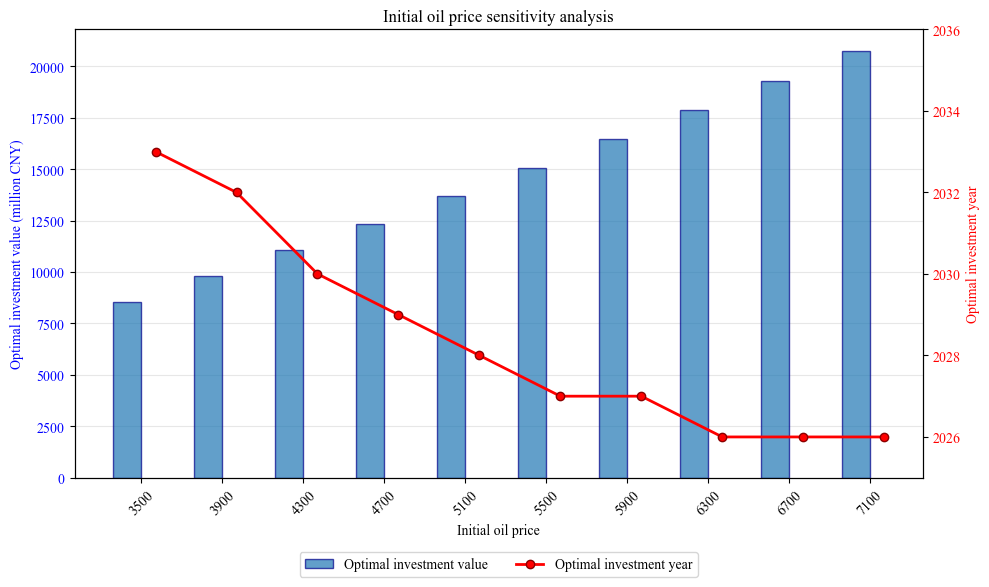

[figure] saved figures\oil_price_drift_sensitivity_analysis.png at 1000 dpi


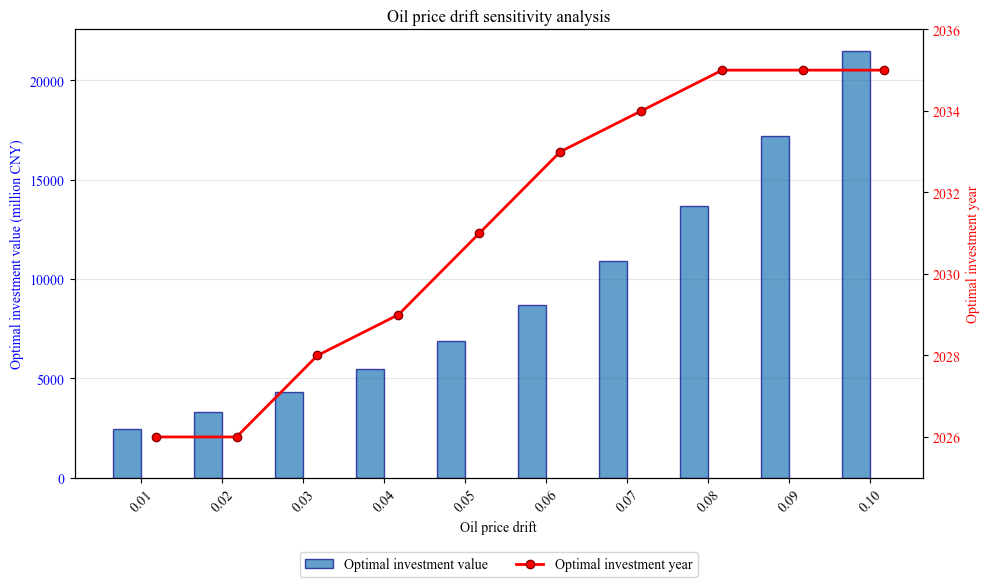

[figure] saved figures\oil_price_volatility_sensitivity_analysis.png at 1000 dpi


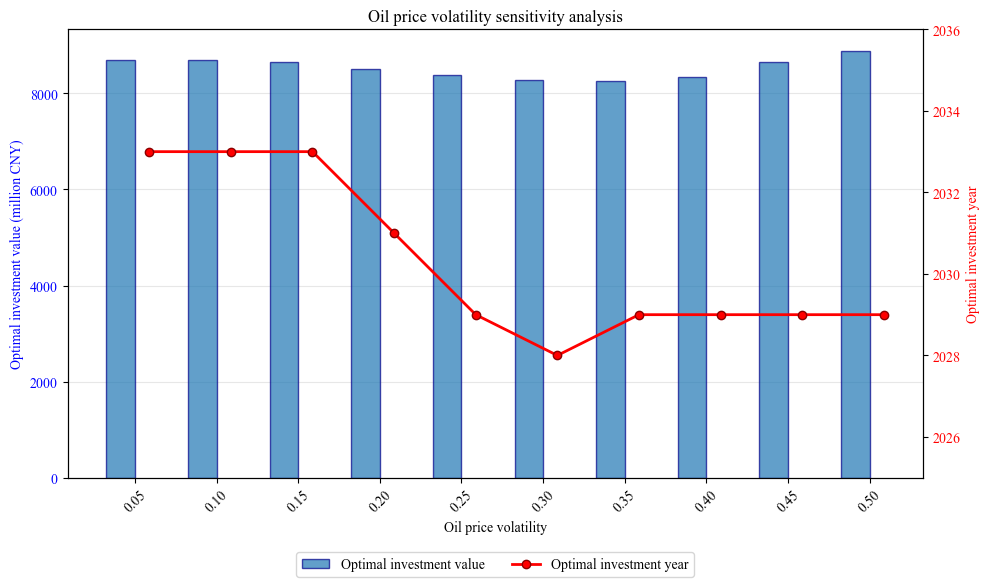

[figure] saved figures\risk_free_rate_sensitivity_analysis.png at 1000 dpi


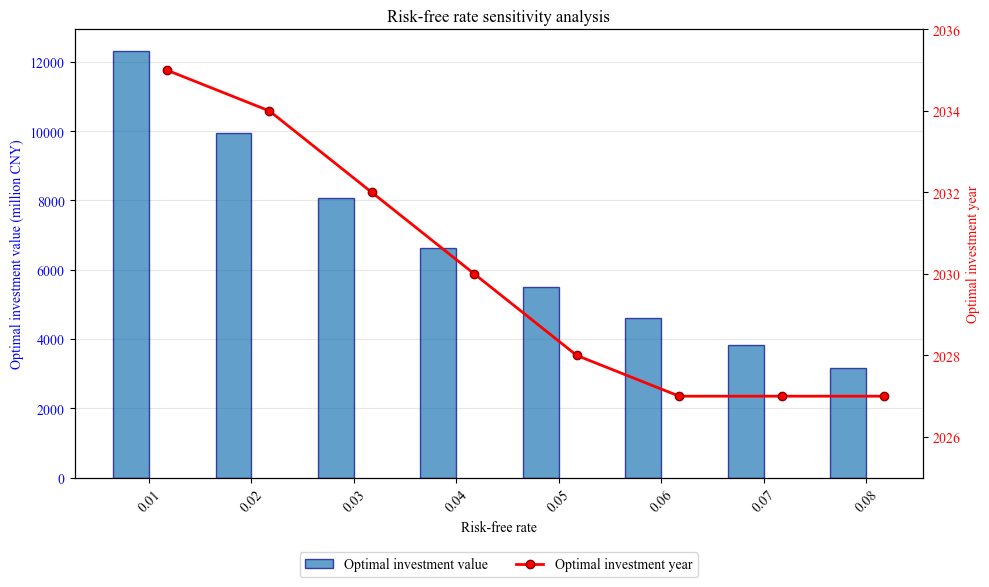

[figure] saved figures\systemic_risk_coefficient_sensitivity_analysis.png at 1000 dpi


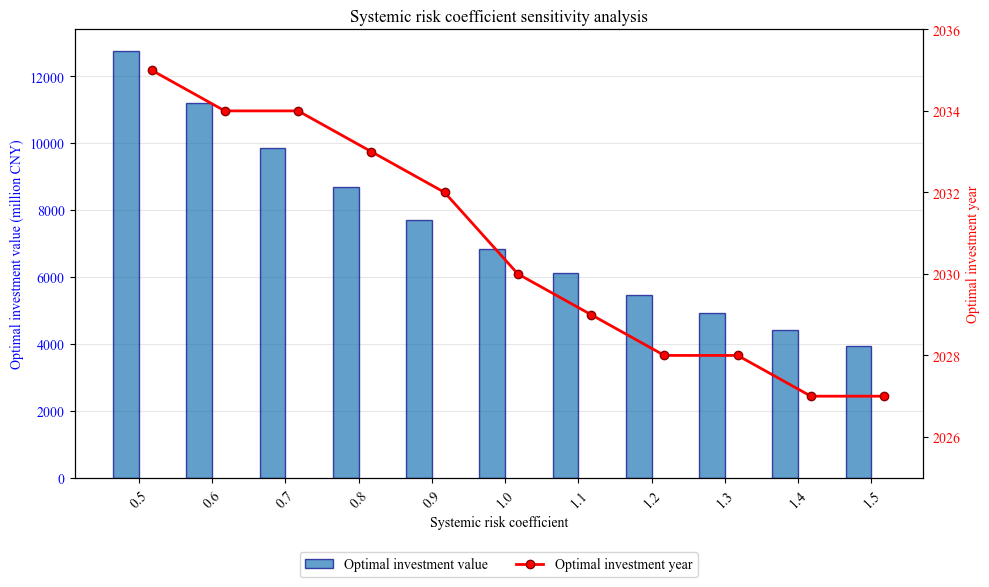

Plotting the sensitivity curves...
[figure] saved figures\investment_value_sensitivity_curve.png at 1000 dpi


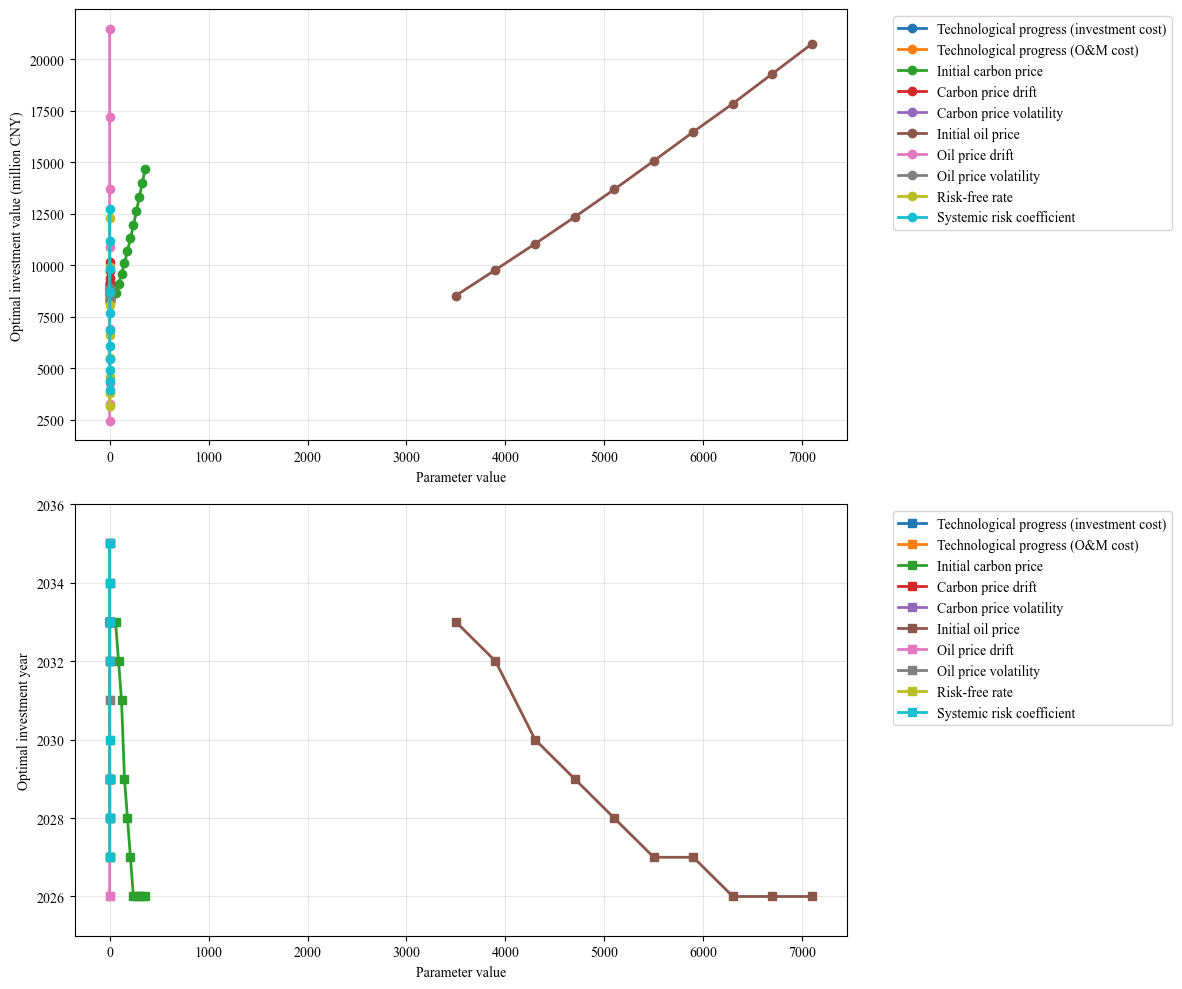

Plotting the sensitivity ranking...
[figure] saved figures\investment_probability_sensitivity_ranking.png at 1000 dpi


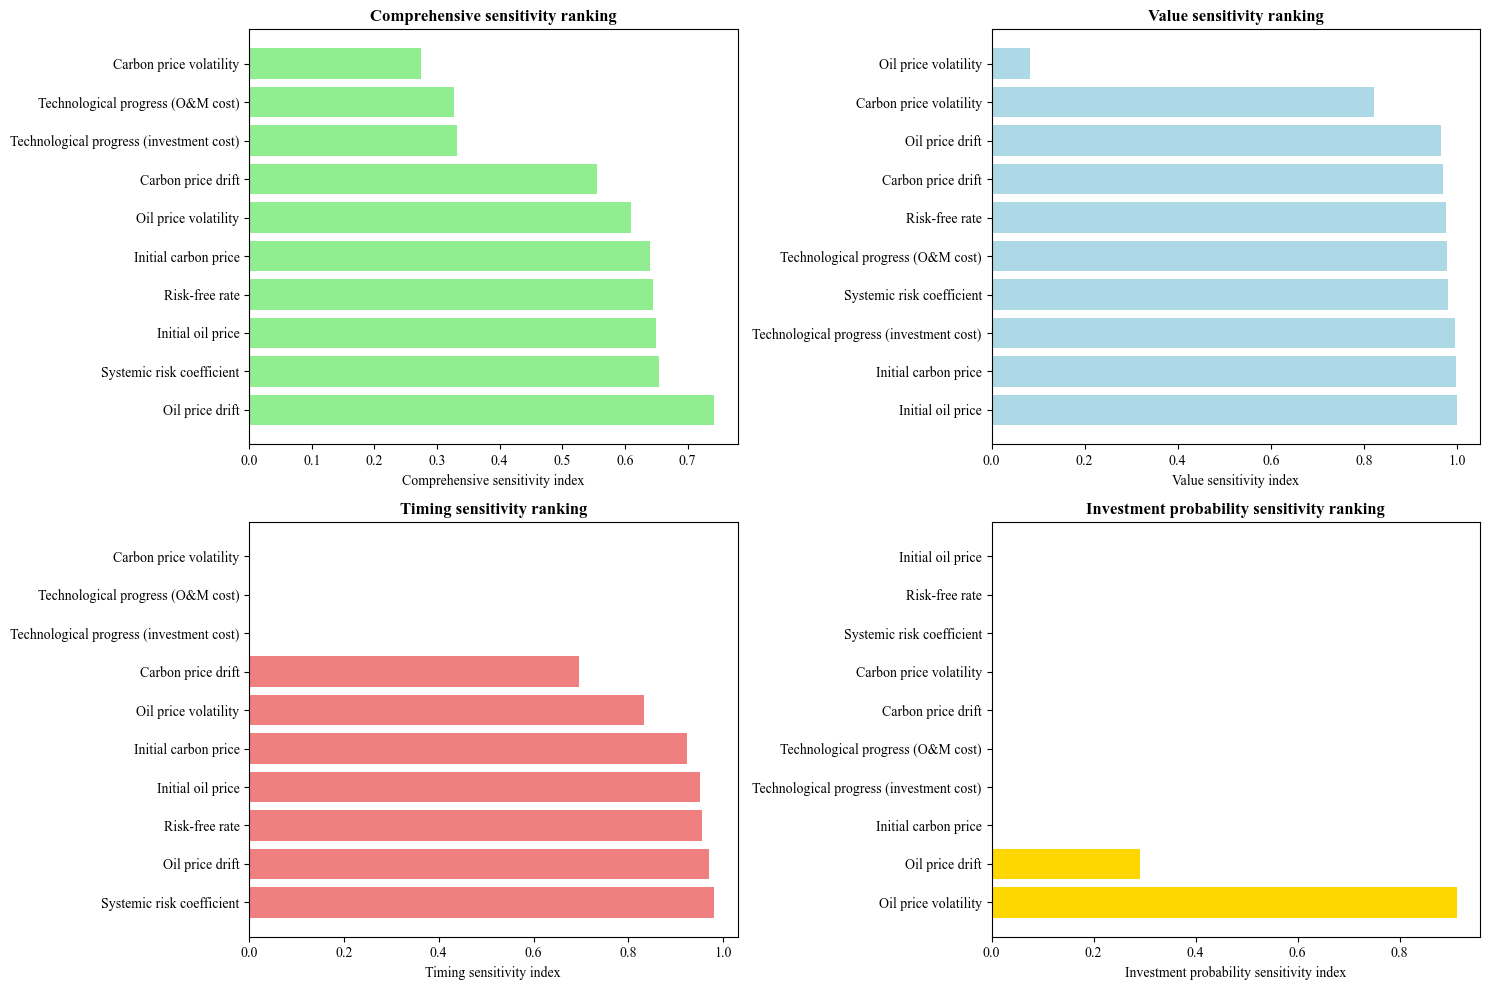

Plotting the tornado chart...
[figure] saved figures\investment_probability_sensitivity_ranking.png at 1000 dpi


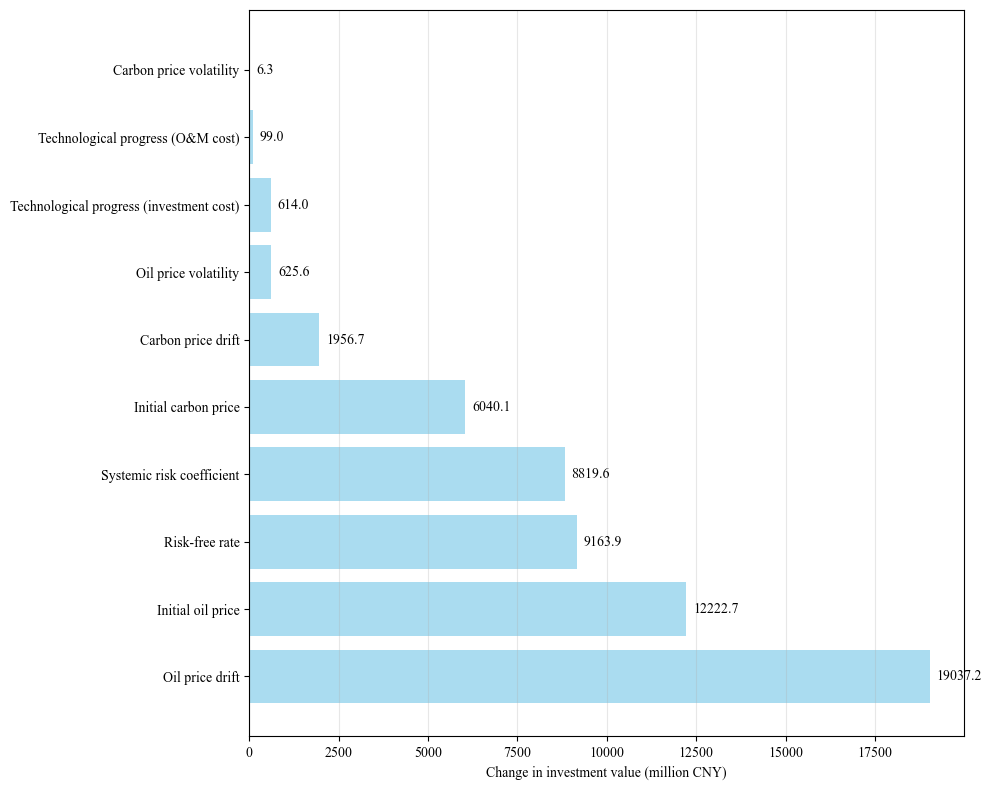


                     CCUS investment decision: sensitivity report

 Baseline statistics:
   Mean optimal investment value: 8985.4 million CNY
   Mean optimal investment year: 2033.0
   Mean investment probability: 100.0%

 Full parameter sensitivity ranking:
Rank Parameter            Comprehensive sensitivity Value sensitivity Timing sensitivity Investment probability sensitivity
------------------------------------------------------------------------------------------
1    Oil price drift      0.7423       0.9664       0.9705       0.2901      
2    Systemic risk coefficient 0.6540       0.9807       0.9812       0.0000      
3    Initial oil price    0.6502       0.9997       0.9508       0.0000      
4    Risk-free rate       0.6439       0.9758       0.9558       0.0000      
5    Initial carbon price 0.6405       0.9977       0.9237       0.0000      
6    Oil price volatility 0.6093       0.0820       0.8337       0.9123      
7    Carbon price drift   0.5552       0.9693       

2284.173703000066

In [20]:
# ============ 3. 运行 ccus_part3.py：敏感性分析（论文附录 A） ============
if "run_script" not in globals():
    raise RuntimeError("请先运行上方第 0 个 cell（环境与工作目录设置）")
run_script("ccus_part3.py")


In [21]:
# ============ 4. 组合政策汇总表（论文表5）：先算技术工具基准，再汇总协同效应 ============
# decompose.py ：为组合情景里的"技术激励"工具单独跑一次基准（即抵免由基准水平
#                提高到现行 45Q 全额抵免），使协同效应的分解口径一致；
# analyze_combos.py ：读取 ccus_scenario_results.csv 与 benchmarks.json，
#                输出各组合的价值增量、协同效应与协同率，并写出
#                ccus_combination_summary.csv（论文表5 的数据源）。
import runpy

for _script in ("decompose.py", "analyze_combos.py"):
    print("=" * 70)
    print("running", _script)
    run_py(_script)


running decompose.py
running decompose.py 
Model initialised: 
  Annual generation: 2,338,908,000 kWh
Electricity price model parameters:
  Initial electricity price: 0.350 CNY/kWh
  Long-run equilibrium price: 0.600 CNY/kWh
  Mean reversion speed: 0.4556
  Electricity price volatility: 0.100
  Correlation with the carbon price: 0.4
  Years in stage one: 5
  Annual CO2 capture: 1,604,023 t
  Annual CO2 injected for EOR: 1,604,023 t
  Annual generation loss: 748,450,560 kWh
  Risk-adjusted discount rate: 0.074
  Time structure: plant life 30 years = decision window 10 years + construction 1 year(s) + dynamic operating period
Simulating uncertainty paths...
Simulating electricity price paths...
Running the least-squares Monte Carlo solver...
Pre-computing the value matrices...
  value matrices: 1000/10000 paths priced
  value matrices: 2000/10000 paths priced
  value matrices: 3000/10000 paths priced
  value matrices: 4000/10000 paths priced
  value matrices: 5000/10000 paths priced
  va

In [22]:
# ============ 5. 对照实验与误差诊断（评审第 7、8 点，独立于三个主脚本） ============
# diagnostics.py 只读取 ccus_part1.py 的模型类与参数定义，输出：
#   A 多随机种子           -> V0 的标准差与 95% 置信区间
#   B 路径数收敛曲线        -> 1000/2500/5000/10000 条路径的 V0 与中位投资年份
#   C 解析算例校验          -> 同一套 LSMC 给美式看跌期权定价 vs 4000 步二叉树解
#   D 方法对照              -> 固定驱油效率 / 固定电价 / 不含 CAPM / 立即投资 /
#                              确定性最优时点
#   E 共同随机数分辨率      -> 情景"差值"的蒙特卡洛噪声
# 产物：diagnostics_results.json、diag_convergence.png
# 约需 30–45 分钟。若想直接查看已保存的结果，把 RUN_DIAGNOSTICS 改为 False。
RUN_DIAGNOSTICS = True

if RUN_DIAGNOSTICS:
    run_py("diagnostics.py", ["10000"])

print("\n" + "=" * 70)
print("diagnostics summary (show_diag.py)")
print("=" * 70)
run_py("show_diag.py")


running diagnostics.py ['10000']
diagnostics: M = 10000, quick = False
0. Reproduction check against ccus_part1_results.csv (M = 10000)
Model initialised: 
  Annual generation: 2,338,908,000 kWh
Electricity price model parameters:
  Initial electricity price: 0.350 CNY/kWh
  Long-run equilibrium price: 0.600 CNY/kWh
  Mean reversion speed: 0.4556
  Electricity price volatility: 0.100
  Correlation with the carbon price: 0.4
  Years in stage one: 5
  Annual CO2 capture: 1,604,023 t
  Annual CO2 injected for EOR: 1,604,023 t
  Annual generation loss: 748,450,560 kWh
  Risk-adjusted discount rate: 0.074
  Time structure: plant life 30 years = decision window 10 years + construction 1 year(s) + dynamic operating period
  diagnostics baseline                           V0=  8,686.4  invest-now=  7,864.4  median=2033.0  modal=2035(26.8%)
   ccus_part1_results.csv V0 = 8,686.37 million CNY; difference = +0.0000 million CNY
A. Multiple random seeds (M = 10000 paths each)
   Note: each run uses 

In [23]:
# ============ 6. 项目级全周期净排放核算（支撑材料口径） ============
# 输入为 ccus_part1.py 生成的 ccus_cashflow_breakdown.csv，不需要重跑模型。
# 指标：增量油产量、增量油燃烧排放、捕集量、净封存量（zeta=0.975）、净减排量。
run_py("net_emissions.py")


running net_emissions.py 
运营年数                 : 23
全周期增油量 (t)         : 5,981,773   (= 43,666,940 bbl)
增油燃烧排放 (tCO2)      : 18,776,784
同期捕集量 (tCO2)        : 36,892,529
净封存量 (ζ=0.975)       : 35,970,216
净排放 = 燃烧 − 净封存   : -17,193,432
净减排比 = 净封存/燃烧   : 1.92

峰值年 (t=8) 增油 (t)    : 712,186
峰值年燃烧排放 (tCO2)    : 2,235,553
峰值年捕集量 (tCO2)      : 1,604,023

若效率曲线改按方案B（峰值仍为0.444，但前期更低）：全周期增油量下降，净排放会进一步恶化；若按方案C（峰值0.764）则相反。
[done] net_emissions.py in 0.0 s


In [24]:
# ============ 7. 45Q 现行法案原文复核与抵免水平敏感性 ============
# fetch_45q.py ：下载并归档 IRS Form 8933 说明与 26 U.S.C. §45Q 原文到 45q_sources/
# grep45q.py   ：在归档原文中检索"12 年申领期""适用美元金额""5 倍加成"等条款
# exp_45q.py   ：比较 35/60/85 美元每吨、含与不含 12 年申领期对 V0 与投资时机的影响
# fetch_45q.py 需要联网；离线时可把 RUN_45Q_AUDIT 设为 False，
# 此时仍会基于 45q_sources/ 中已归档的原文执行检索。
RUN_45Q_AUDIT = True

if RUN_45Q_AUDIT:
    try:
        run_py("fetch_45q.py")
    except Exception as _exc:               # 无网络时不中断整个 notebook
        print("fetch_45q.py could not reach the internet (%s); "
              "falling back to the archived 45q_sources/." % _exc)

for _f in ("irs_form8933_instructions_2025-12.txt", "usc_45Q_current.txt"):
    print("\n" + "-" * 70)
    print("key clauses in", _f)
    run_py("grep45q.py", [_f])

print("\n" + "=" * 70)
print("45Q credit-level sensitivity (exp_45q.py)")
print("=" * 70)
run_py("exp_45q.py", ["1500"])


running fetch_45q.py 
### irs_form8933_instructions_2025-12  (88831 chars)  https://www.irs.gov/instructions/i8933
    written to C:\Users\Administrator\Desktop\ccus\code\45q_sources\irs_form8933_instructions_2025-12.txt
  --[12-year period] ...rmined under section 45Q(b)(1)) per metric ton of qualified carbon oxide (1) captured by you using equipment that’s originally placed in service at a facility on or after February 9, 2018, during the 12-year period beginning on the date the equipment was originally placed in service, (2) disposed of by you in secure geological storage, and (3) neither used as a tertiary injectant in an EOR or natural gas recovery project nor utilized in a manner desc...
  --[applicable dollar amount] ... 
 
 
 
 
 
 
 
 
 
 
 

 


 

 

 

 
 

 

 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 Instructions for Form 8933 - Introductory Material 
 
 Future Developments 

 What’s New 
 
 Credit rates and applicable dollar amounts. 

 New credit rate for facilities or

In [25]:
# ============ 8. 产物清单 ============
fig_dir = BASE_DIR / "figures"
figs = sorted(fig_dir.glob("*.png")) if fig_dir.exists() else []
print("images (figures/):" if figs else "images (figures/): none")
for f in figs:
    print("   %-58s %8.1f MB" % (f.name, f.stat().st_size / 1e6))

csvs = sorted(BASE_DIR.glob("*.csv"))
print("\ndata tables (same folder as this notebook):" if csvs else "\ndata tables: none")
for f in csvs:
    print("   %-58s %8.1f KB" % (f.name, f.stat().st_size / 1e3))

aux = sorted(list(BASE_DIR.glob("*.json")) + list((BASE_DIR / "45q_sources").glob("*.txt")))
print("\nauxiliary results (JSON / archived sources):" if aux else "\nauxiliary results: none")
for f in aux:
    print("   %-58s %8.1f KB" % (f.name, f.stat().st_size / 1e3))

latest = {}
for f in list(BASE_DIR.glob("*.csv")) + list(BASE_DIR.glob("*.json")):
    latest[f.name] = f.stat().st_mtime
print("\n提示：控制台输出 + 上述 CSV/JSON + figures/ 即为论文与支撑材料的全部数值来源。")


images (figures/):
   a_simulated_carbon_price_paths_full_project_cycle.png           5.1 MB
   c_distribution_of_optimal_investment_timing.png                 0.5 MB
   carbon_price_drift_sensitivity_analysis.png                     0.7 MB
   carbon_price_volatility_sensitivity_analysis.png                0.7 MB
   carbon_trading_carbon_trading_revenue_scaled_up_step_by_step.png      2.3 MB
   combo_carbon_subsidy_policy_intensity.png                       2.3 MB
   combo_carbon_subsidy_tax_policy_intensity.png                   2.2 MB
   combo_carbon_subsidy_tax_technology_policy_intensity.png        2.2 MB
   combo_carbon_subsidy_technology_policy_intensity.png            2.1 MB
   combo_carbon_tax_policy_intensity.png                           2.4 MB
   combo_carbon_tax_technology_policy_intensity.png                2.3 MB
   combo_carbon_technology_policy_intensity.png                    2.2 MB
   combo_subsidy_tax_policy_intensity.png                          2.3 MB
   combo_subs